In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import math

In [3]:
#!/bin/bash
!kaggle datasets download prachi13/customer-analytics -p ./data

Dataset URL: https://www.kaggle.com/datasets/prachi13/customer-analytics
License(s): other
customer-analytics.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
import os

HOME = os.getcwd()
# 압축 파일의 위치
zipPath = os.path.join(HOME, 'data','customer-analytics.zip')
# 압축 해제 할 위치
targetPath = os.path.join(HOME, 'data')

In [5]:
from zipfile import ZipFile

with ZipFile(zipPath, 'r') as zip_ref:
    zip_ref.extractall(targetPath)

In [6]:
trainPath = os.path.join(targetPath, 'Train.csv')
df = pd.read_csv(trainPath)
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [8]:
df.isna().sum()

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

In [9]:
TARGET = 'Reached.on.Time_Y.N'
target = 'Reached.on.Time_Y.N'

빠른 분석을 위해 레이블 인코딩 후 히트맵 시각화

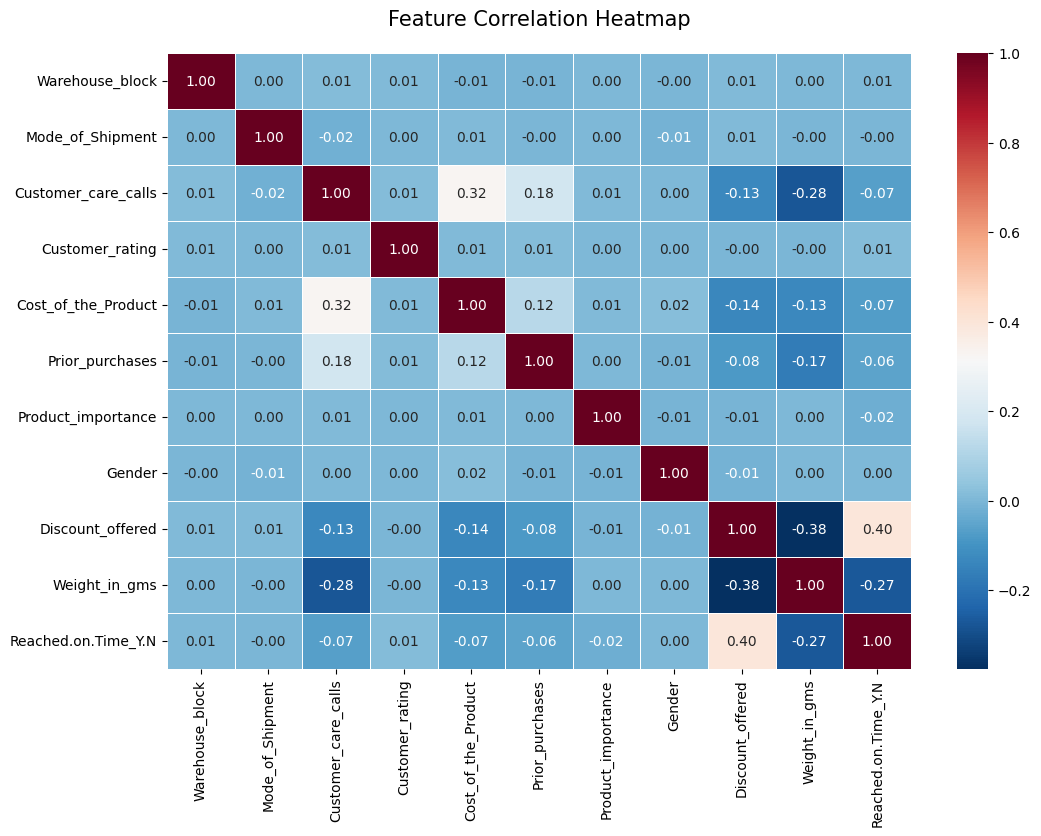

In [10]:


data = df.copy().drop(columns=['ID'])

# 범주형 변수 라벨 인코딩
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
object_cols = data.select_dtypes(include=['object']).columns

for col in object_cols:
    data[col] = le.fit_transform(data[col])

# 히트맵 시각화
plt.figure(figsize=(12, 8)) 
sns.heatmap(data.corr(), annot=True, fmt='.2f', 
            cmap='RdBu_r', 
            linewidths=0.5, annot_kws={'size': 10})
plt.title('Feature Correlation Heatmap', fontsize=15, pad=20)
plt.show()

유의미한 상관계수
* Discount_offered: 0.4
* Weight_in_gms: -0.27

그 외의 가능성 있는 항목
* Cost_of_the_Product: -0.07
* Customer_care_calls: -0.07
* prior_purchases: -0.06

검증용 데이터 분리

In [11]:
# 1. stratify 옵션을 써서 정답(Reached.on.Time_Y.N) 비율을 유지하며 8:2로 나눕니다.
# 이 함수는 내부적으로 데이터를 랜덤하게 섞어주기 때문에 sample을 따로 안 써도 됩니다.
part1, part2 = train_test_split(df, 
                                test_size=0.2, 
                                random_state=42, 
                                stratify=df['Reached.on.Time_Y.N'])

# 2. 각각 파일로 저장
part1.to_csv('data/train_df.csv', index=False)
part2.to_csv('data/test_df.csv', index=False)

print("데이터 분할 및 저장 완료!")
print(f"학습용: {part1.shape}, 테스트용: {part2.shape}")

데이터 분할 및 저장 완료!
학습용: (8799, 12), 테스트용: (2200, 12)


In [12]:
train_df = pd.read_csv('data/train_df.csv')
test_df = pd.read_csv('data/test_df.csv')
train_df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,7921,D,Road,4,1,261,2,medium,F,9,4158,0
1,1530,F,Ship,3,3,162,2,low,F,26,1659,1
2,10522,B,Ship,3,2,221,2,medium,M,9,4466,0
3,9559,D,Ship,3,5,157,4,medium,F,2,4640,0
4,969,A,Flight,2,5,272,2,low,M,24,3638,1


In [13]:
# target 데이터의 분포가 6:4로 비슷하게 이루어져 있음
print(f"배송 지연 확률: {train_df['Reached.on.Time_Y.N'].mean() * 100:.2f}%")

배송 지연 확률: 59.67%


| 컬럼명 (Column Name) | 설명 (Description) | 구분/범위 (Value Range) | 비고 (Additional Notes) |
| :--- | :--- | :--- | :--- |
| **ID** | 고객 고유 번호 | 숫자 (Numeric) | 인덱스. 정보 가치 없음|
| **Warehouse block** | 창고 구역 | A, B, C, D, E | 대규모 창고 내 구역 구분 |
| **Mode of shipment** | 배송 수단 | Ship, Flight, Road | 선박, 항공, 육로 배송 |
| **Customer care calls** | 고객 센터 문의 횟수 | 숫자 (Numeric) | 배송 관련 문의 전화 건수 |
| **Customer rating** | 고객 만족도 평점 | 1(낮음) ~ 5(높음) | 배송에 대한 만족도가 아닐수 있음에 주의 |
| **Cost of the product** | 제품 가격 | US 달러 ($) | 해당 제품의 판매가 |
| **Prior purchases** | 이전 구매 횟수 | 숫자 (Numeric) | 해당 고객의 과거 구매 이력 |
| **Product importance** | 제품 중요도 | low, medium, high | 중요도의 기준이 무엇인지 확인 불가 |
| **Gender** | 성별 | Male, Female |  |
| **Discount offered** | 할인액 | 1~65의 정수 | 할인 금액. 할인율과 다를것으로 추측 |
| **Weight in gms** | 제품 무게 | 그램 (g) | 제품의 실제 무게 |
| **Reached on time** | **정시 도착 여부** | 0: 정시, 1: 지연 | **타겟 변수 (Target Variable)** |

#### 특성 분류
범주형과 수치형의 분리

In [14]:
def split_feature_types(df, threshold=10):
    """
    ID를 제외하고 범주형과 수치형을 분리합니다.
    수치형 중에서도 고유값(unique) 개수가 threshold 이하이면 범주형으로 간주합니다.
    """
    temp_df = df.copy()
    if 'ID' in temp_df.columns:
        temp_df = temp_df.drop(columns=['ID'])
        
    # 타겟 제외
    target_name = 'Reached.on.Time_Y.N'
    features = [col for col in temp_df.columns if col != target_name]
    
    cat_cols = []
    num_cols = []
    
    for col in features:
        # 1. 데이터 타입이 object/category거나, 고유값 개수가 적은 경우 범주형으로 분류
        if temp_df[col].dtype in ['object', 'category'] or temp_df[col].nunique() <= threshold:
            cat_cols.append(col)
        # 2. 그 외에는 수치형으로 분류
        else:
            num_cols.append(col)

    print(f'범주형:{cat_cols}')
    print(f'숫자형:{num_cols}')
    return cat_cols, num_cols

In [15]:
cat_cols, num_cols = split_feature_types(train_df)

범주형:['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Prior_purchases', 'Product_importance', 'Gender']
숫자형:['Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms']


### 시각화 함수 정의

In [16]:
# 범주형 특성의 시각화

target = 'Reached.on.Time_Y.N'

def plot_categorical_analysis(df, features, target):
    """
    범주형 특성 리스트를 받아 왼쪽에는 빈도 분포(Count), 
    오른쪽에는 타겟 지연율(Rate)을 나란히 시각화합니다.
    """
    num_features = len(features)
    # 한 행에 한 특성씩(왼쪽/오른쪽 두 개 그래프) 배치하므로 rows는 특성 개수와 같습니다.
    rows = num_features 
    
    plt.figure(figsize=(10, rows * 3))
    plt.suptitle('Categorical Feature Analysis: Distribution vs Delay Rate', fontsize=14, fontweight='bold', y=1.01)

    for i, col in enumerate(features):
        
        if df[col].dtype.name == 'category':
            order = df[col].cat.categories.tolist()
        else:
            order = sorted(df[col].unique())
        
        # --- 왼쪽: 빈도 분포 (Count Plot) ---
        plt.subplot(rows, 2, i * 2 + 1)
        sns.countplot(x=col, data=df, order=order, palette='Pastel1', hue=col, legend=False)
        plt.title(f'{col} Distribution', fontsize=10)
        plt.xlabel('') # 가독성을 위해 x축 레이블 생략 가능
       
        # --- 오른쪽: 지연율 (Delay Rate Bar Plot) ---
        plt.subplot(rows, 2, i * 2 + 2)
        # 지연율 계산
        ax = sns.barplot(
            x=col, y=target, data=df, order=order, 
            palette='viridis', hue=col, legend=False, errorbar=None
        )
        
        # 전체 평균 지연율 기준선
        avg_rate = df[target].mean()
        ax.axhline(avg_rate, color='red', linestyle='--', alpha=0.6)
        
        # 수치 표시 (%)
        for p in ax.patches:
            height = p.get_height()
            ax.annotate(f'{height:.1%}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='center', fontsize=9, xytext=(0, 5),
                        textcoords='offset points')

        plt.title(f'{col} Delay Rate', fontsize=10)
        plt.xlabel('')
        plt.ylabel('')
        plt.ylim(0, 1.1)
    
    plt.tight_layout()
    plt.show()

In [17]:
# 수치형 특성의 시각화

def plot_numeric_analysis(df, features, target):
    """
    수치형 특성 리스트를 받아 한 행에 KDE, Boxplot, Histogram+KDE를 시각화합니다.
    """
    num_features = len(features)
    # 한 행에 3개씩 배치
    plt.figure(figsize=(18, num_features * 4))
    plt.suptitle('Numerical Feature Analysis: KDE vs Boxplot vs Histogram', fontsize=18, fontweight='bold', y=1.02)

    for i, col in enumerate(features):
        # 1. KDE Plot: 두 그룹의 밀도 곡선 비교
        plt.subplot(num_features, 3, i*3 + 1)
        sns.kdeplot(data=df, x=col, hue=target, fill=True, common_norm=False, palette='viridis', alpha=0.5)
        plt.title(f'{col} - Density Curve', fontsize=12)

        # 2. Boxplot: 중앙값 및 이상치 확인
        plt.subplot(num_features, 3, i*3 + 2)
        sns.boxplot(data=df, x=target, y=col, hue=target, palette='viridis', legend=False)
        plt.title(f'{col} - Outliers & Range', fontsize=12)
        
        # 3. Histogram + KDE: 실제 데이터 빈도와 곡선 결합
        plt.subplot(num_features, 3, i*3 + 3)
        sns.histplot(data=df, x=col, hue=target, kde=True, element="step", palette='viridis', alpha=0.3)
        plt.title(f'{col} - Histogram (Step)', fontsize=12)

    plt.tight_layout()
    plt.show()

### 각 특성별 지연율

In [18]:
# 시각화 가독성을 위해 범주 순서 정렬
importance_order = ['low', 'medium', 'high']
train_df['Product_importance'] = pd.Categorical(train_df['Product_importance'], 
                                         categories=importance_order, 
                                         ordered=True)

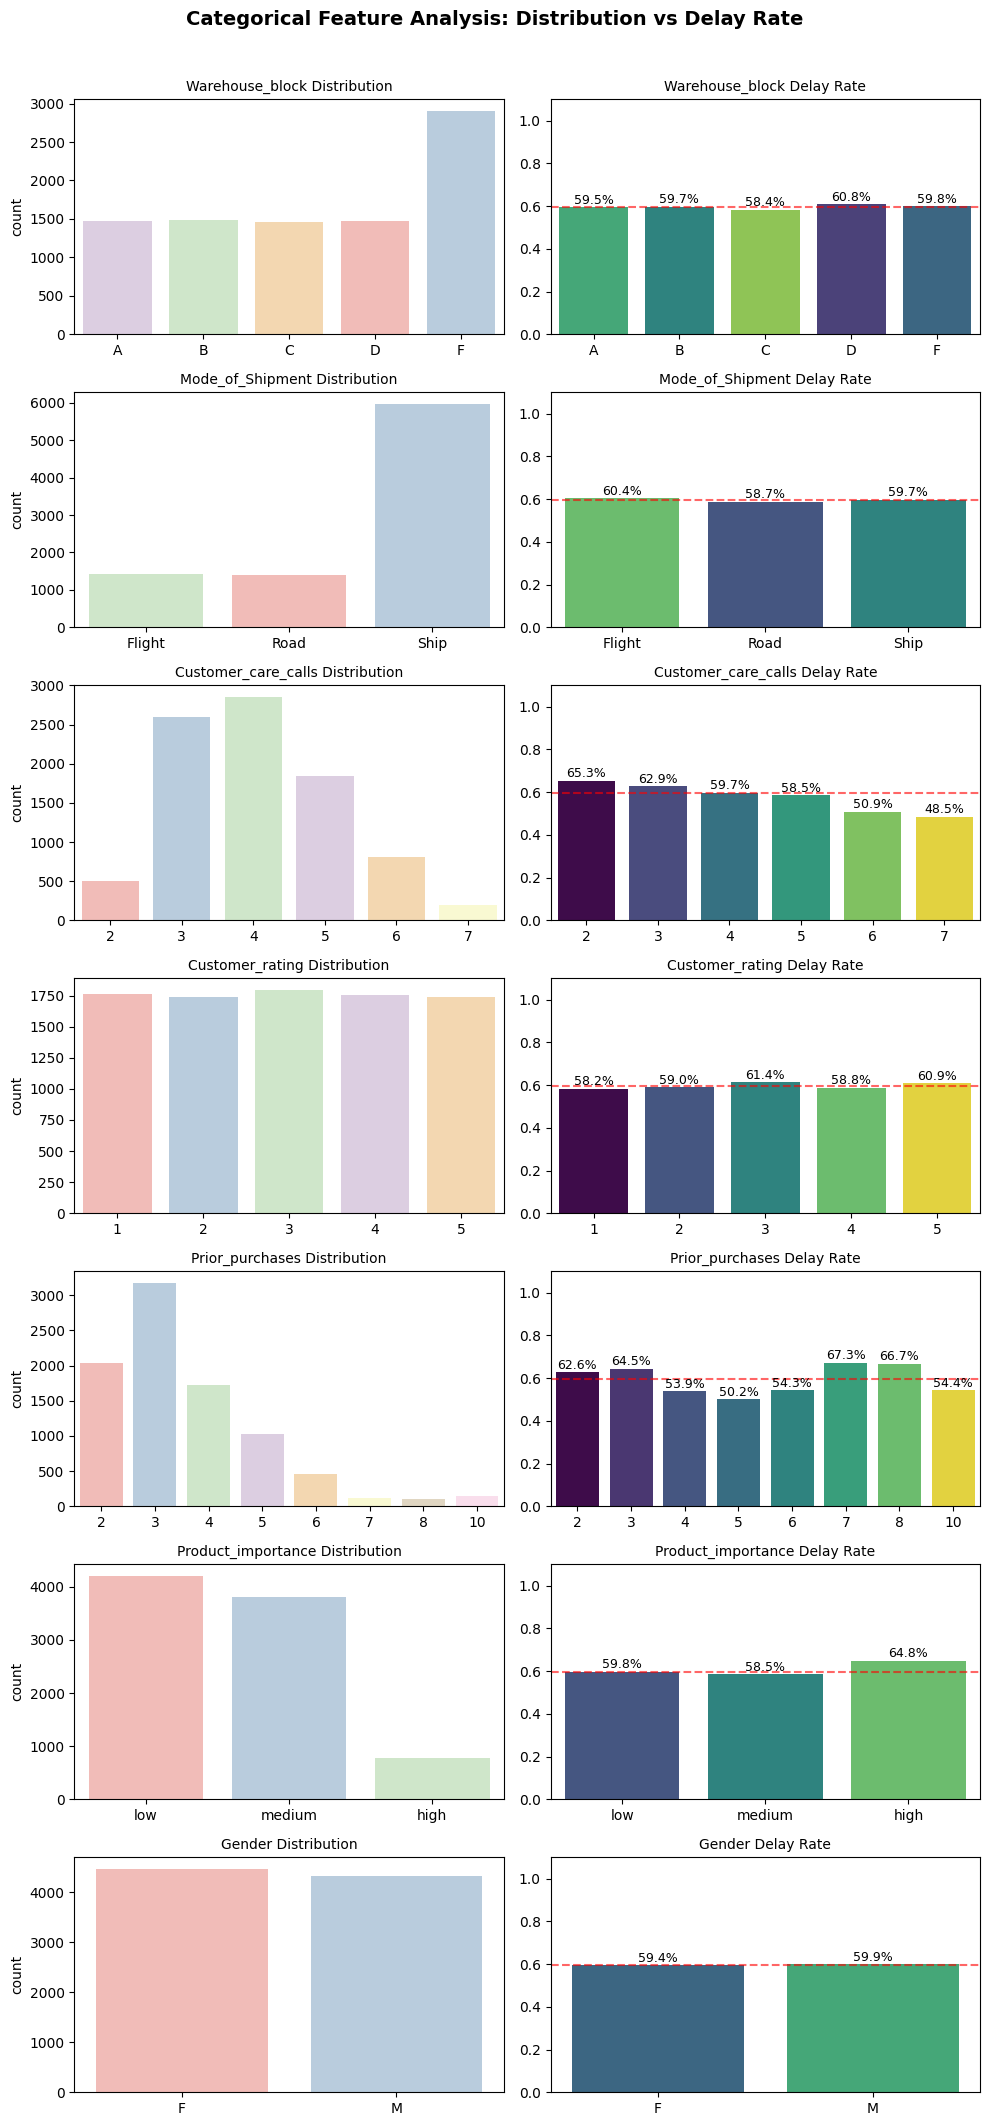

In [19]:
plot_categorical_analysis(train_df, cat_cols, target)

* Warehouse_block에서 f의 비중이 큰 것을 발견 <br>
	-> 하지만 지연율 차이 미미
* Mode_of_Shipment은 Ship에 집중 <br>
	 ->하지만 지연율 차이 미미
* Customer_care_calls는 2, 6, 7의 데이터 크기가 작음 <br>
	 ->많아질수록 지연율 떨어짐. 6 이후를 하나로 묶을 필요성
* Customer_rating은 분포가 고르다 <br>
	 ->지연율 차이도 미미
* Prior_purchases는 6 이후의 분포가 적음 <br>
	 ->지연율은 4,5,6에서 감소. 6 이후를 통합
* Product_importance는 High에서 오히려 높은 지연율 <br>
	-> importance의 기준이 무엇인지 확인 필요
* Gender에 따른 지연율의 차이 없음

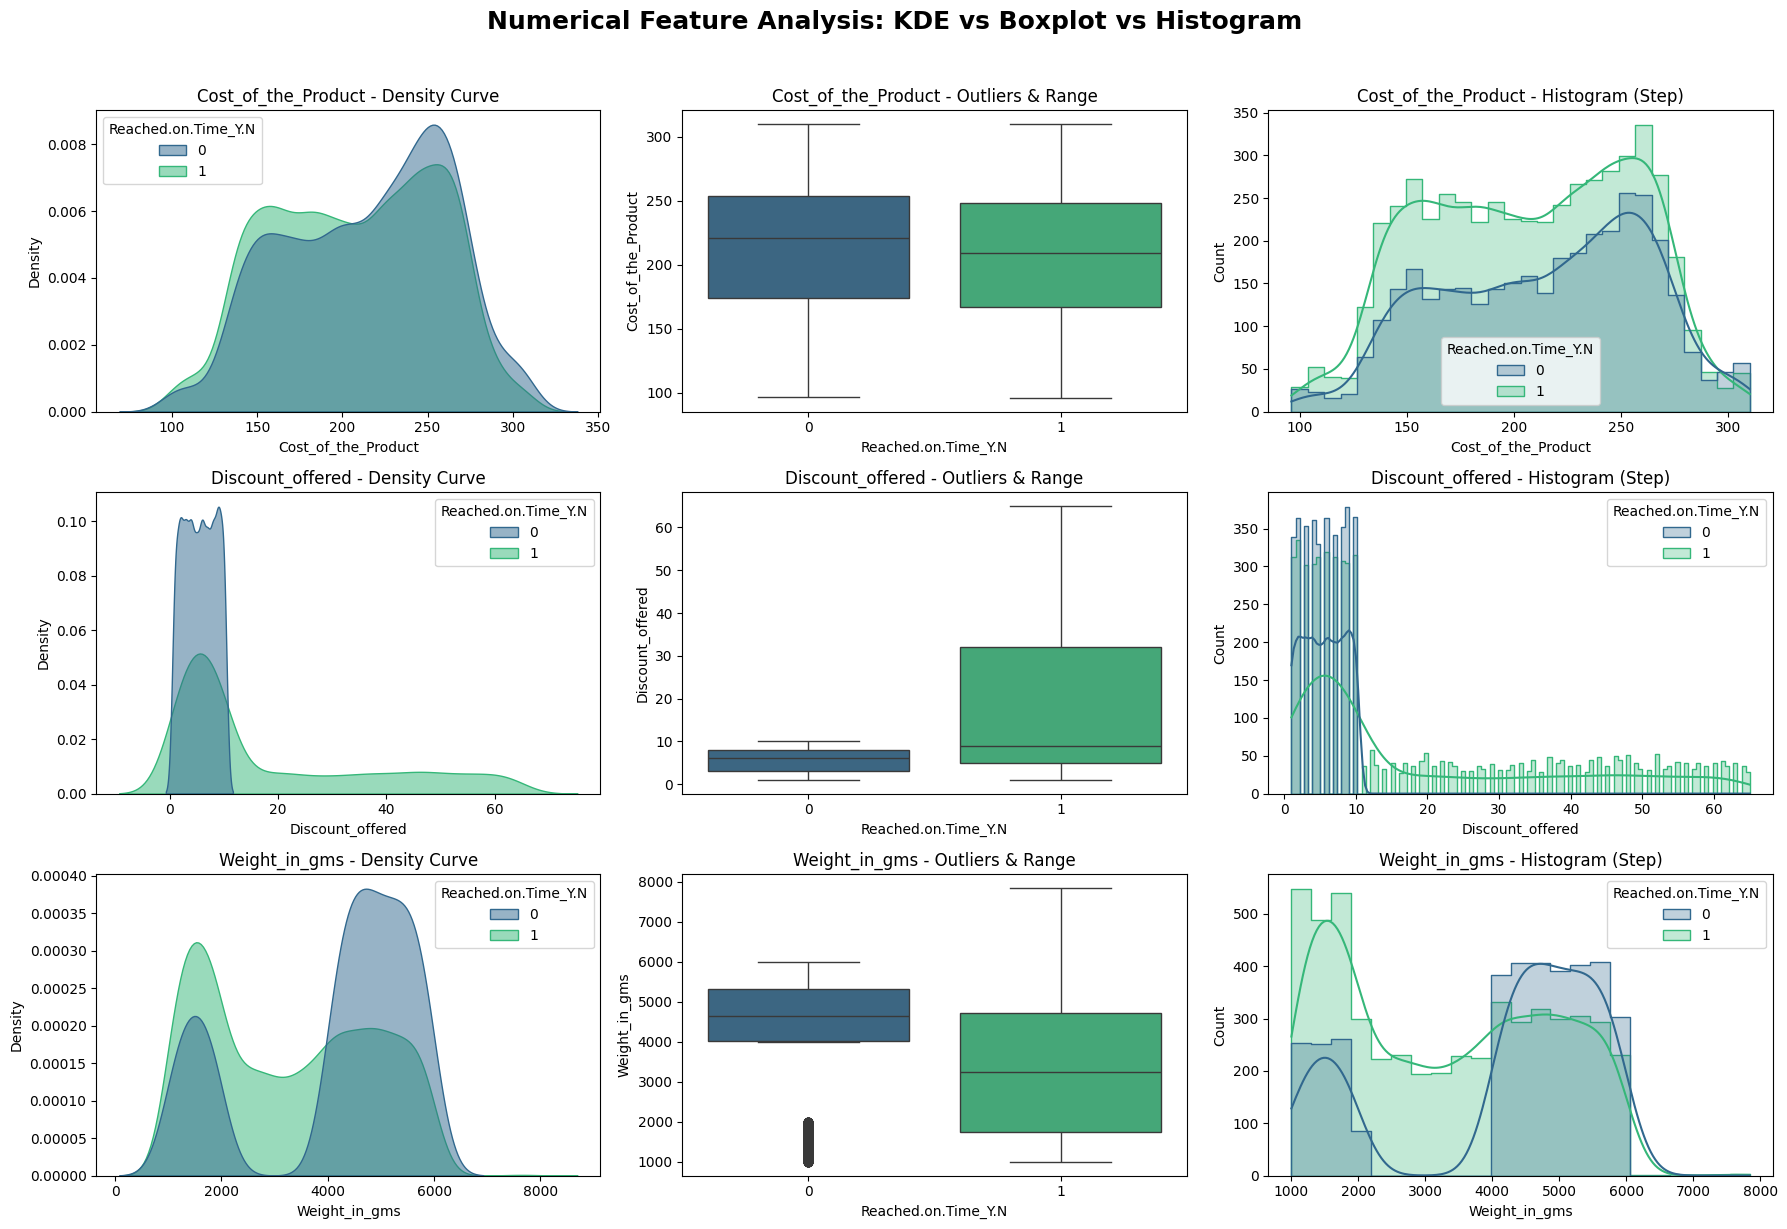

In [20]:
plot_numeric_analysis(train_df, num_cols, target)

* Cost_of_the_product는 큰 영향 없는듯 보인다
    -> 다른 특성과 결합하여 가능한 변수 만들어보기
* Discount_offered는 10 초과는 지연
    -> 10을 기준으로 구분 필요
* Weight_in_gms는 구간에 따른 지연율 차이
    -> 낮은 구간, 중간 구간, 높은 구간의 지연율이 각각 다름

## EDA

1. 특성간 분포 변화를 살펴보고 관계성 추측
    * 하나의 특성에 다른 features는 어떤 분포를 하는지 시각적으로 확인할 수 있는 함수 생성
    * 이상치 여부를 판단하는 로직을 넣어 효율적으로 데이터 탐색
2. 새로운 파생변수 생성 및 지연율에 대한 영향력 확인

### 특성간 비교 함수 정의

In [21]:
# 범주형 특성과의 관계 분석 함수

def summarize_categorical_with_plots(df, group_col, target_features, threshold=5.0):
    """
    각 창고별 비율과 전체 비율(Overall)을 비교하여 
    차이가 threshold(%p) 이상인 경우에만 표를 출력합니다.
    """
    filtered_features = [col for col in target_features if col != group_col]
    
    for col in filtered_features:
        # 1. 그룹별 빈도 및 비율 계산
        count_table = pd.crosstab(df[group_col], df[col])
        percent_table = pd.crosstab(df[group_col], df[col], normalize='index') * 100
        
        # 2. 전체 데이터(Overall) 비율 및 빈도 계산
        overall_counts = df[col].value_counts().reindex(count_table.columns)
        overall_percents = (df[col].value_counts(normalize=True) * 100).reindex(count_table.columns)
        
        # 3. 이상치 여부 판단 (어떤 그룹이라도 전체 평균과 threshold 이상 차이가 나는가?)
        is_outlier = False
        for category in overall_percents.index:
            diff = (percent_table[category] - overall_percents[category]).abs()
            if diff.max() >= threshold:
                is_outlier = True
                break
        
        # 4. 결과 출력
        if is_outlier:
            print(f"\n[🚨 이상치 발견] '{col}' 특성은 {group_col}별로 유의미한 차이가 있습니다.")
            
            # 5. 빈도와 비율을 합친 요약 테이블 생성
            summary_table = count_table.copy().astype(str)
            for row in count_table.index:
                for c in count_table.columns:
                    summary_table.loc[row, c] = f"{count_table.loc[row, c]} ({percent_table.loc[row, c]:.1f}%)"
            
            # 6. Overall(전체 평균) 행 추가
            overall_row = []
            for c in count_table.columns:
                overall_row.append(f"{overall_counts[c]} ({overall_percents[c]:.1f}%)")
            
            summary_table.loc['Overall'] = overall_row
            
            display(summary_table)


            # --- [시각화 데이터 준비] ---
            # 표와 동일한 구조를 위해 Overall을 포함한 Wide format 생성
            plot_df_wide = percent_table.copy()
            plot_df_wide.loc['Overall'] = overall_percents
            
            # 그래프용 Long format 변환
            plot_df_long = plot_df_wide.reset_index().melt(id_vars=group_col, var_name=col, value_name='Percentage')

            # --- [그래프 그리기] ---
            plt.figure(figsize=(10, 5))
            
            # 범례 순서를 표의 컬럼 순서와 동일하게 고정
            category_order = list(count_table.columns)
            
            ax = sns.barplot(
                data=plot_df_long, y=group_col, x='Percentage', hue=col, hue_order=category_order, palette='viridis' )
            
            # 막대 옆에 % 수치 표시
            for p in ax.patches:
                width = p.get_width()
                if width > 0:
                    ax.annotate(f' {width:.1f}%', 
                                (width, p.get_y() + p.get_height() / 2.), 
                                ha='left', va='center', fontsize=9, fontweight='bold', xytext=(3, 0), textcoords='offset points')

            plt.title(f'Distribution of {col} by {group_col}', fontsize=14, pad=20)
            plt.xlabel('Percentage (%)')
            plt.ylabel(group_col)
            plt.xlim(0, plot_df_long['Percentage'].max() * 1.2) # 수치 표시 공간 확보
            plt.legend(title=col, bbox_to_anchor=(1.02, 1), loc='upper left')
            plt.grid(axis='x', linestyle='--', alpha=0.3)
            plt.tight_layout()
            plt.show()

            
        else:
            print(f"[✅ 이상치 없음] '{col}': 모든 {group_col}에서 고른 분포를 보입니다.")

In [22]:
# 수치형 특성과의 관계 분석 함수

def summarize_numeric_with_plots(df, group_col, target_features, threshold=0.1):
    """
    수치형 특성의 그룹별 통계량과 전체 분포를 비교 시각화합니다.
    """
    for col in target_features:
        if col == group_col: continue
        
        # 1. 통계량 계산
        group_stats = df.groupby(group_col, observed=True)[col].describe()
        overall_stats = df[col].describe()
        
        # 2. 이상치 판단 (그룹 평균이 전체 평균과 threshold 이상 차이 나는지)
        mean_diff = (group_stats['mean'] - overall_stats['mean']).abs() / overall_stats['mean']
        
        if mean_diff.max() >= threshold:
            print(f"\n[🚨 차이 발견] '{col}' 특성은 {group_col}별로 평균 차이가 있습니다.")
            display(group_stats)

            # --- [시각화 시작] ---
            plt.figure(figsize=(12, 6))
            
            # (1) Box Plot 그리기
            ax = sns.boxplot(data=df, x=group_col, y=col, hue=group_col, palette='viridis', legend=False, showmeans=True,
                             meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"})
            
            # (2) 전체 평균(Overall Mean) 수평선 추가
            plt.axhline(overall_stats['mean'], color='red', linestyle='--', linewidth=2, label=f'Overall Mean: {overall_stats["mean"]:.2f}')
            
            # (3) 각 그룹별 평균값을 텍스트로 표시
            means = df.groupby(group_col, observed=True)[col].mean()
            for i, mean in enumerate(means):
                ax.annotate(f'{mean:.2f}', xy=(i, mean), xytext=(0, 10),
                            textcoords='offset points', ha='center', fontsize=10, fontweight='bold', color='blue')

            plt.title(f'Comparison: {col} Distribution by {group_col}', fontsize=15)
            plt.legend(loc='upper right')
            plt.grid(axis='y', linestyle=':', alpha=0.7)
            plt.show()
        else:
            print(f"[✅ 통과] '{col}': 그룹별 평균 차이가 미미합니다.")

In [23]:
print(cat_cols)
print(num_cols)

['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Prior_purchases', 'Product_importance', 'Gender']
['Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms']


In [24]:
# 데이터의 분포가 너무 적어 비교가 어려운 부분은 범주를 합친다.
train_df['Prior_purchases'] = train_df['Prior_purchases'].clip(upper=6)
train_df['Customer_care_calls'] = train_df['Customer_care_calls'].clip(lower=3, upper=6)

### 특성 간 분포 단순 비교

In [25]:
summarize_categorical_with_plots(train_df, 'Warehouse_block', cat_cols, threshold=5.0)

[✅ 이상치 없음] 'Mode_of_Shipment': 모든 Warehouse_block에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Customer_care_calls': 모든 Warehouse_block에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Customer_rating': 모든 Warehouse_block에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Prior_purchases': 모든 Warehouse_block에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Product_importance': 모든 Warehouse_block에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Gender': 모든 Warehouse_block에서 고른 분포를 보입니다.


In [26]:
summarize_numeric_with_plots(train_df, 'Warehouse_block', num_cols, threshold=0.1)

[✅ 통과] 'Cost_of_the_Product': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Discount_offered': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Weight_in_gms': 그룹별 평균 차이가 미미합니다.


In [27]:
summarize_categorical_with_plots(train_df, 'Mode_of_Shipment', cat_cols, threshold=5.0)

[✅ 이상치 없음] 'Warehouse_block': 모든 Mode_of_Shipment에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Customer_care_calls': 모든 Mode_of_Shipment에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Customer_rating': 모든 Mode_of_Shipment에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Prior_purchases': 모든 Mode_of_Shipment에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Product_importance': 모든 Mode_of_Shipment에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Gender': 모든 Mode_of_Shipment에서 고른 분포를 보입니다.


In [28]:
summarize_numeric_with_plots(train_df, 'Mode_of_Shipment', num_cols, threshold=0.1)

[✅ 통과] 'Cost_of_the_Product': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Discount_offered': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Weight_in_gms': 그룹별 평균 차이가 미미합니다.


[✅ 이상치 없음] 'Warehouse_block': 모든 Customer_care_calls에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Mode_of_Shipment': 모든 Customer_care_calls에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Customer_rating': 모든 Customer_care_calls에서 고른 분포를 보입니다.

[🚨 이상치 발견] 'Prior_purchases' 특성은 Customer_care_calls별로 유의미한 차이가 있습니다.


Prior_purchases,2,3,4,5,6
Customer_care_calls,,,,,
3,910 (29.4%),1370 (44.2%),424 (13.7%),132 (4.3%),264 (8.5%)
4,731 (25.6%),1184 (41.4%),351 (12.3%),323 (11.3%),270 (9.4%)
5,366 (19.9%),548 (29.8%),279 (15.2%),425 (23.1%),220 (12.0%)
6,35 (3.5%),80 (8.0%),669 (66.8%),147 (14.7%),71 (7.1%)
Overall,2042 (23.2%),3182 (36.2%),1723 (19.6%),1027 (11.7%),825 (9.4%)


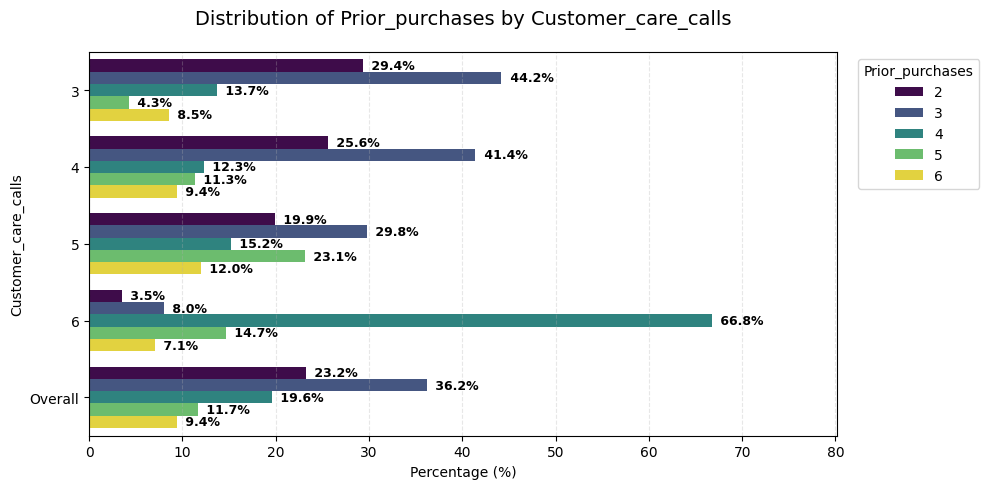


[🚨 이상치 발견] 'Product_importance' 특성은 Customer_care_calls별로 유의미한 차이가 있습니다.


Product_importance,low,medium,high
Customer_care_calls,,,
3,1395 (45.0%),1371 (44.2%),334 (10.8%)
4,1370 (47.9%),1264 (44.2%),225 (7.9%)
5,892 (48.5%),790 (43.0%),156 (8.5%)
6,557 (55.6%),392 (39.1%),53 (5.3%)
Overall,4214 (47.9%),3817 (43.4%),768 (8.7%)


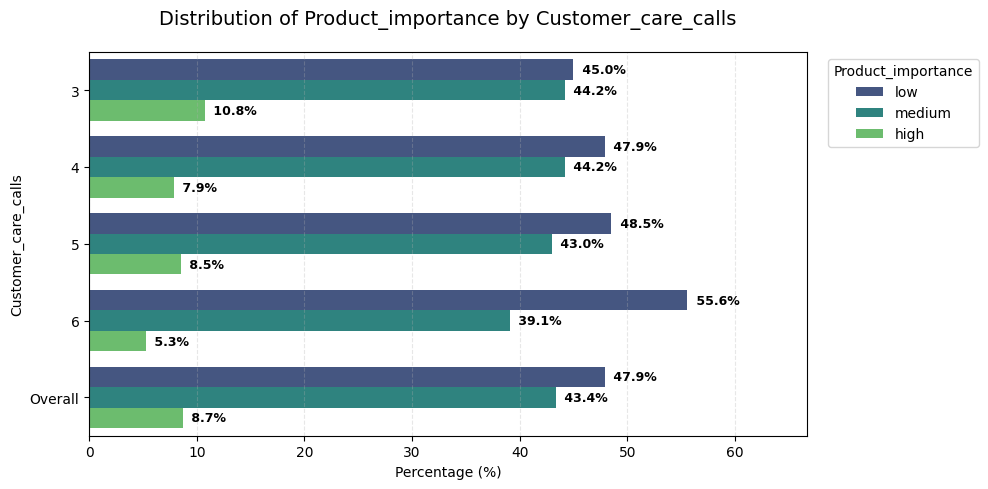

[✅ 이상치 없음] 'Gender': 모든 Customer_care_calls에서 고른 분포를 보입니다.


In [29]:
summarize_categorical_with_plots(train_df, 'Customer_care_calls', cat_cols, threshold=5.0)


[🚨 차이 발견] 'Cost_of_the_Product' 특성은 Customer_care_calls별로 평균 차이가 있습니다.


,count,mean,std,min,25%,50%,75%,max
Customer_care_calls,,,,,,,,
3,3100.0,198.072581,45.021721,96.0,160.00,197.0,237.0,310.0
4,2859.0,205.861840,44.537105,96.0,168.00,209.0,245.0,301.0
5,1838.0,214.638738,44.470881,97.0,179.00,225.0,251.0,307.0
6,1002.0,252.222555,49.119107,98.0,242.25,265.0,286.0,310.0


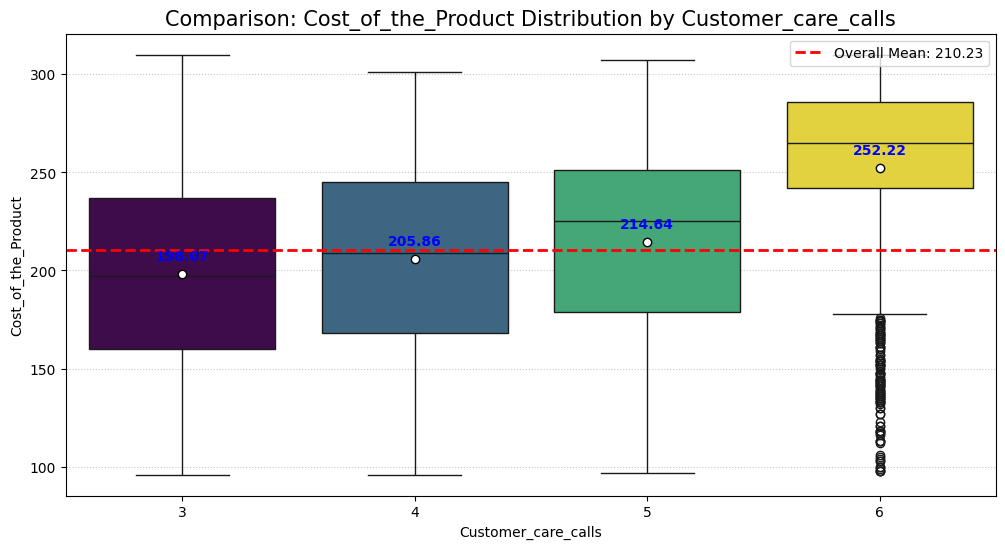


[🚨 차이 발견] 'Discount_offered' 특성은 Customer_care_calls별로 평균 차이가 있습니다.


,count,mean,std,min,25%,50%,75%,max
Customer_care_calls,,,,,,,,
3,3100.0,15.415484,17.528522,1.0,4.0,8.0,19.0,65.0
4,2859.0,13.380553,16.102605,1.0,4.0,7.0,11.0,65.0
5,1838.0,12.633841,15.638064,1.0,4.0,7.0,10.0,65.0
6,1002.0,8.335329,10.579575,1.0,3.0,6.0,9.0,65.0


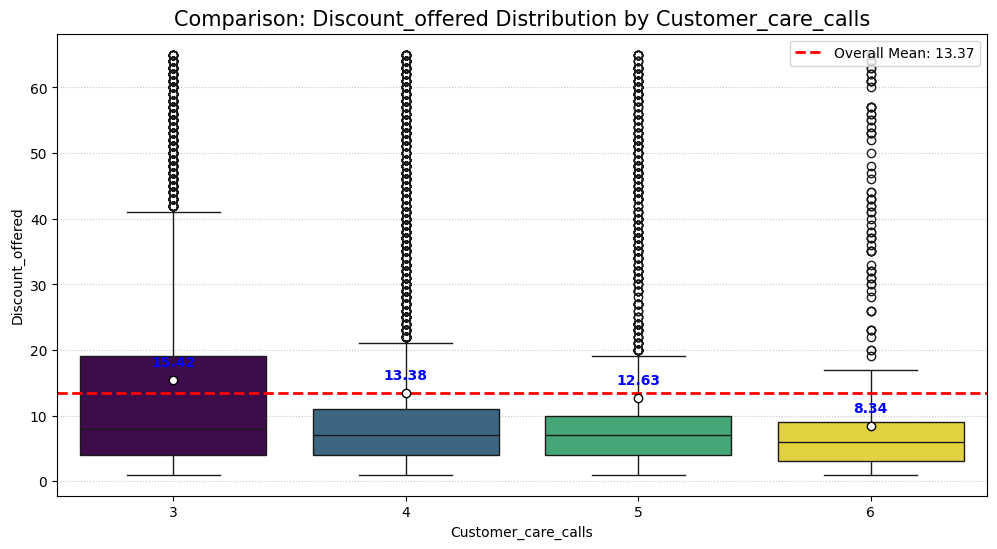


[🚨 차이 발견] 'Weight_in_gms' 특성은 Customer_care_calls별로 평균 차이가 있습니다.


,count,mean,std,min,25%,50%,75%,max
Customer_care_calls,,,,,,,,
3,3100.0,3969.918387,1498.540805,1004.0,2727.00,4372.5,5184.25,7846.0
4,2859.0,3844.457503,1568.115869,1001.0,2270.50,4331.0,5148.50,6000.0
5,1838.0,3468.522307,1653.171112,1001.0,1730.50,3917.0,4946.00,6000.0
6,1002.0,2273.432136,1450.641967,1003.0,1303.25,1660.0,2334.00,5992.0


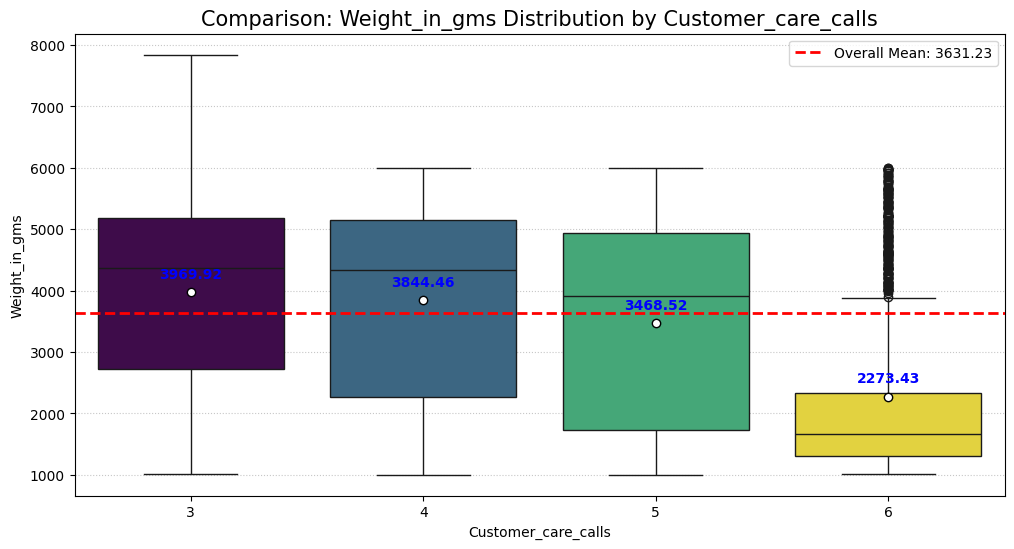

In [30]:
summarize_numeric_with_plots(train_df, 'Customer_care_calls', num_cols, threshold=0.1)

In [31]:
summarize_categorical_with_plots(train_df, 'Customer_rating', cat_cols, threshold=5.0)

[✅ 이상치 없음] 'Warehouse_block': 모든 Customer_rating에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Mode_of_Shipment': 모든 Customer_rating에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Customer_care_calls': 모든 Customer_rating에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Prior_purchases': 모든 Customer_rating에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Product_importance': 모든 Customer_rating에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Gender': 모든 Customer_rating에서 고른 분포를 보입니다.


In [32]:
summarize_numeric_with_plots(train_df, 'Customer_rating', num_cols, threshold=0.1)

[✅ 통과] 'Cost_of_the_Product': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Discount_offered': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Weight_in_gms': 그룹별 평균 차이가 미미합니다.


[✅ 이상치 없음] 'Warehouse_block': 모든 Prior_purchases에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Mode_of_Shipment': 모든 Prior_purchases에서 고른 분포를 보입니다.

[🚨 이상치 발견] 'Customer_care_calls' 특성은 Prior_purchases별로 유의미한 차이가 있습니다.


Customer_care_calls,3,4,5,6
Prior_purchases,,,,
2,910 (44.6%),731 (35.8%),366 (17.9%),35 (1.7%)
3,1370 (43.1%),1184 (37.2%),548 (17.2%),80 (2.5%)
4,424 (24.6%),351 (20.4%),279 (16.2%),669 (38.8%)
5,132 (12.9%),323 (31.5%),425 (41.4%),147 (14.3%)
6,264 (32.0%),270 (32.7%),220 (26.7%),71 (8.6%)
Overall,3100 (35.2%),2859 (32.5%),1838 (20.9%),1002 (11.4%)


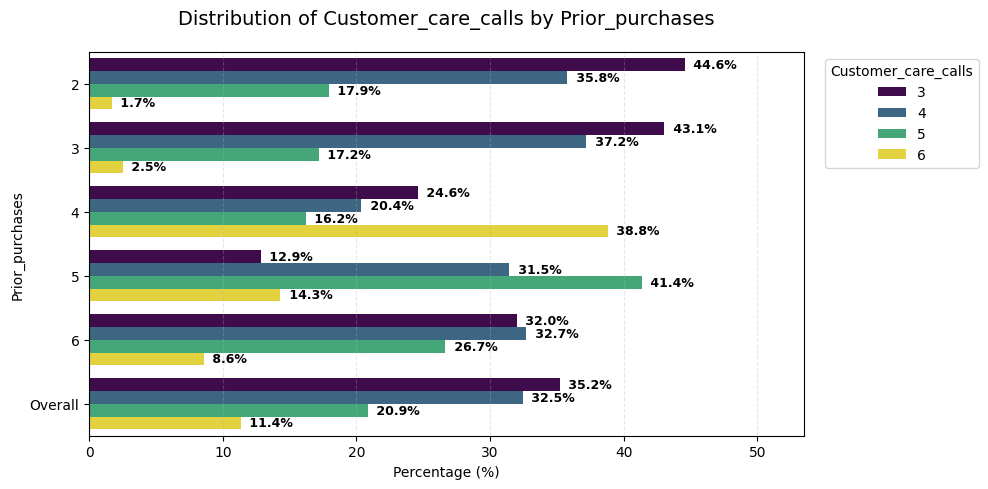

[✅ 이상치 없음] 'Customer_rating': 모든 Prior_purchases에서 고른 분포를 보입니다.

[🚨 이상치 발견] 'Product_importance' 특성은 Prior_purchases별로 유의미한 차이가 있습니다.


Product_importance,low,medium,high
Prior_purchases,,,
2,949 (46.5%),894 (43.8%),199 (9.7%)
3,1486 (46.7%),1387 (43.6%),309 (9.7%)
4,887 (51.5%),723 (42.0%),113 (6.6%)
5,574 (55.9%),411 (40.0%),42 (4.1%)
6,318 (38.5%),402 (48.7%),105 (12.7%)
Overall,4214 (47.9%),3817 (43.4%),768 (8.7%)


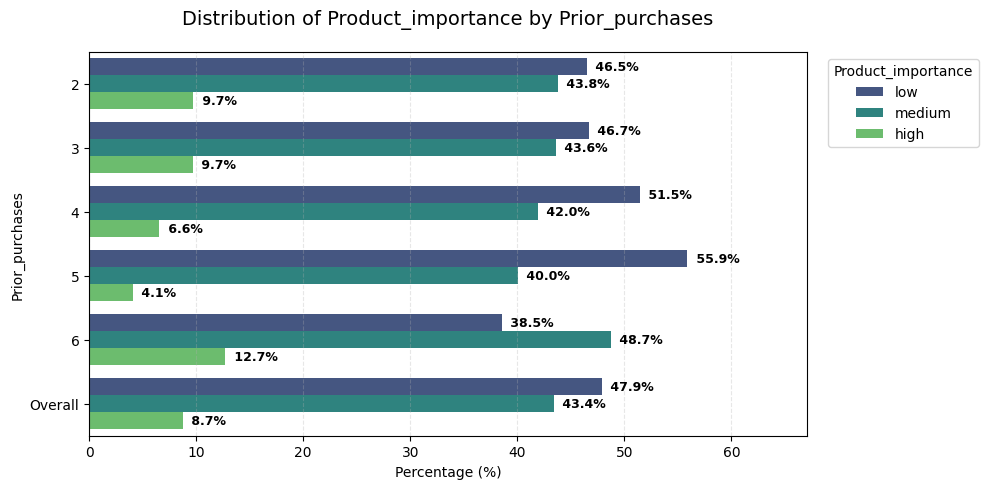

[✅ 이상치 없음] 'Gender': 모든 Prior_purchases에서 고른 분포를 보입니다.


In [33]:
summarize_categorical_with_plots(train_df, 'Prior_purchases', cat_cols, threshold=5.0)

[✅ 통과] 'Cost_of_the_Product': 그룹별 평균 차이가 미미합니다.

[🚨 차이 발견] 'Discount_offered' 특성은 Prior_purchases별로 평균 차이가 있습니다.


,count,mean,std,min,25%,50%,75%,max
Prior_purchases,,,,,,,,
2,2042.0,15.292360,17.313979,1.0,4.0,8.0,20.0,65.0
3,3182.0,15.174104,17.422930,1.0,4.0,7.0,19.0,65.0
4,1723.0,10.647127,13.727382,1.0,3.0,7.0,10.0,65.0
5,1027.0,9.397274,12.121377,1.0,3.0,6.0,9.0,65.0
6,825.0,12.253333,15.314346,1.0,4.0,7.0,10.0,65.0


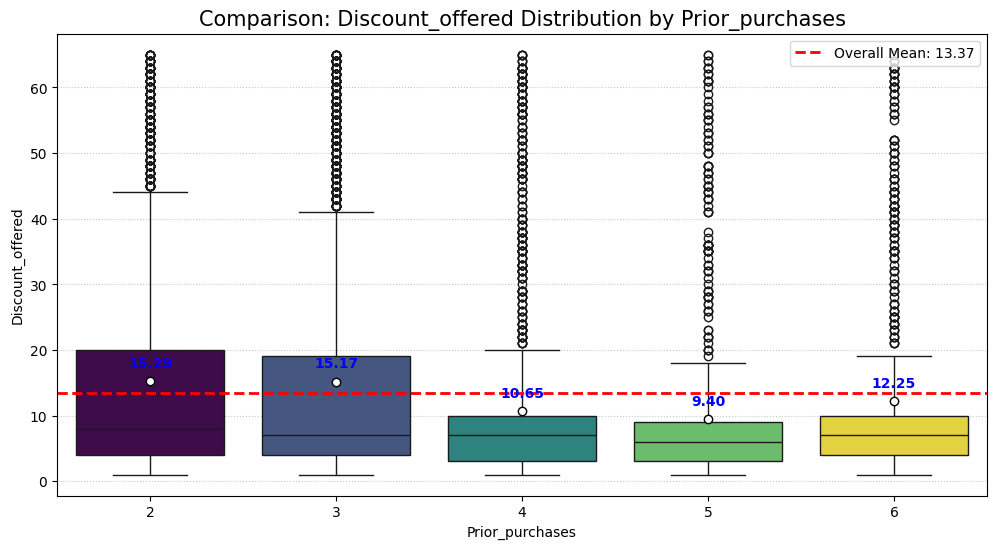


[🚨 차이 발견] 'Weight_in_gms' 특성은 Prior_purchases별로 평균 차이가 있습니다.


,count,mean,std,min,25%,50%,75%,max
Prior_purchases,,,,,,,,
2,2042.0,4011.672870,1451.756663,1001.0,2858.50,4374.5,5190.00,6000.0
3,3182.0,4035.417976,1474.620793,1005.0,2866.25,4427.5,5213.75,7846.0
4,1723.0,3122.888566,1702.390639,1003.0,1535.50,2583.0,4781.00,5989.0
5,1027.0,2462.910419,1544.628663,1001.0,1357.50,1736.0,4056.50,5993.0
6,825.0,3646.656970,1624.899209,1003.0,1861.00,4179.0,5035.00,5995.0


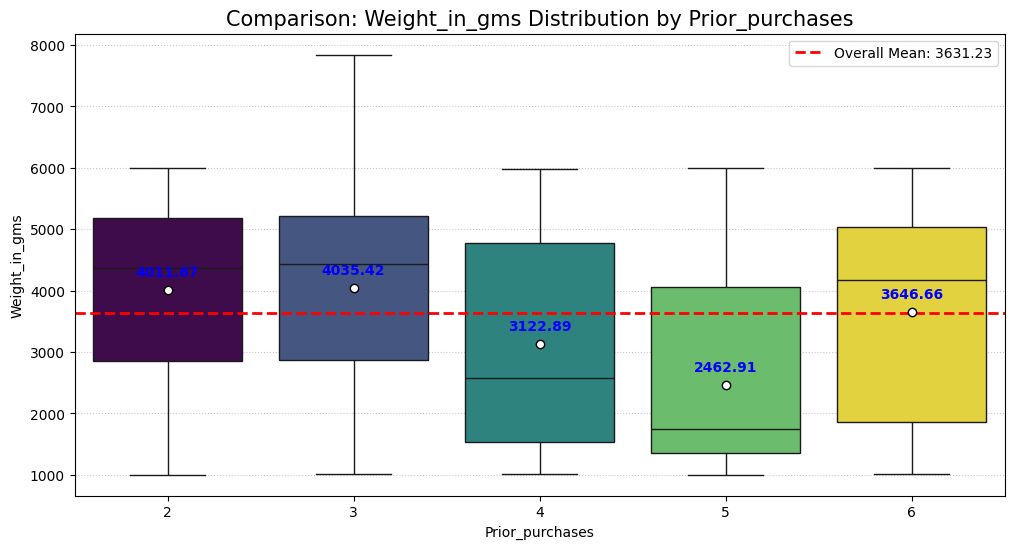

In [34]:
summarize_numeric_with_plots(train_df, 'Prior_purchases', num_cols, threshold=0.1)

[✅ 이상치 없음] 'Warehouse_block': 모든 Product_importance에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Mode_of_Shipment': 모든 Product_importance에서 고른 분포를 보입니다.

[🚨 이상치 발견] 'Customer_care_calls' 특성은 Product_importance별로 유의미한 차이가 있습니다.


Customer_care_calls,3,4,5,6
Product_importance,,,,
low,1395 (33.1%),1370 (32.5%),892 (21.2%),557 (13.2%)
medium,1371 (35.9%),1264 (33.1%),790 (20.7%),392 (10.3%)
high,334 (43.5%),225 (29.3%),156 (20.3%),53 (6.9%)
Overall,3100 (35.2%),2859 (32.5%),1838 (20.9%),1002 (11.4%)


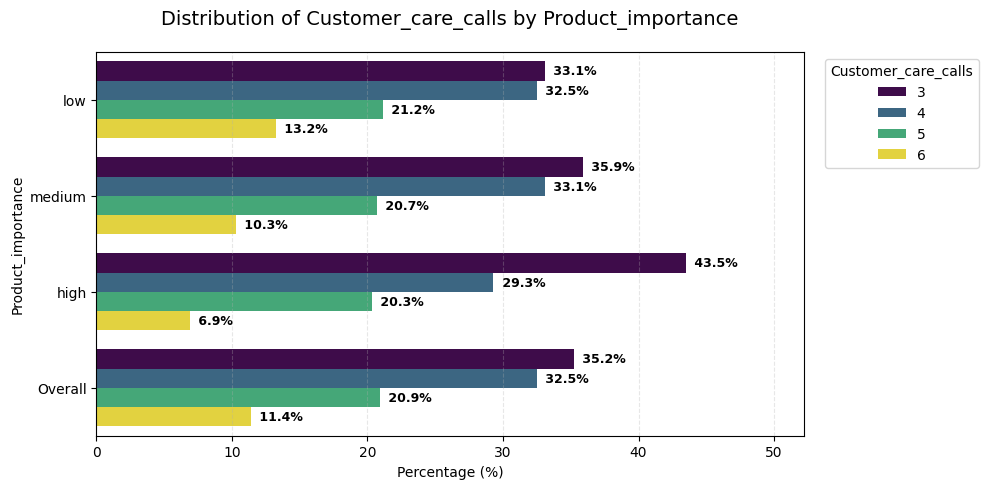

[✅ 이상치 없음] 'Customer_rating': 모든 Product_importance에서 고른 분포를 보입니다.

[🚨 이상치 발견] 'Prior_purchases' 특성은 Product_importance별로 유의미한 차이가 있습니다.


Prior_purchases,2,3,4,5,6
Product_importance,,,,,
low,949 (22.5%),1486 (35.3%),887 (21.0%),574 (13.6%),318 (7.5%)
medium,894 (23.4%),1387 (36.3%),723 (18.9%),411 (10.8%),402 (10.5%)
high,199 (25.9%),309 (40.2%),113 (14.7%),42 (5.5%),105 (13.7%)
Overall,2042 (23.2%),3182 (36.2%),1723 (19.6%),1027 (11.7%),825 (9.4%)


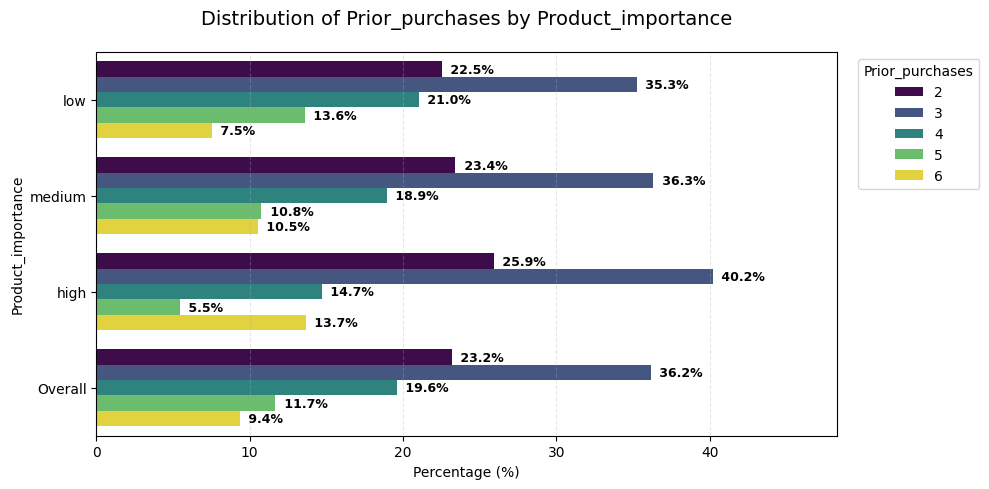

[✅ 이상치 없음] 'Gender': 모든 Product_importance에서 고른 분포를 보입니다.


In [35]:
summarize_categorical_with_plots(train_df, 'Product_importance', cat_cols, threshold=5.0)

[✅ 통과] 'Cost_of_the_Product': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Discount_offered': 그룹별 평균 차이가 미미합니다.

[🚨 차이 발견] 'Weight_in_gms' 특성은 Product_importance별로 평균 차이가 있습니다.


,count,mean,std,min,25%,50%,75%,max
Product_importance,,,,,,,,
low,4214.0,3474.928334,1669.890264,1001.0,1714.00,3996.0,4986.75,5999.0
medium,3817.0,3727.875033,1605.159900,1001.0,1936.00,4212.0,5082.00,7846.0
high,768.0,4008.498698,1474.420311,1007.0,2868.25,4402.0,5195.50,6000.0


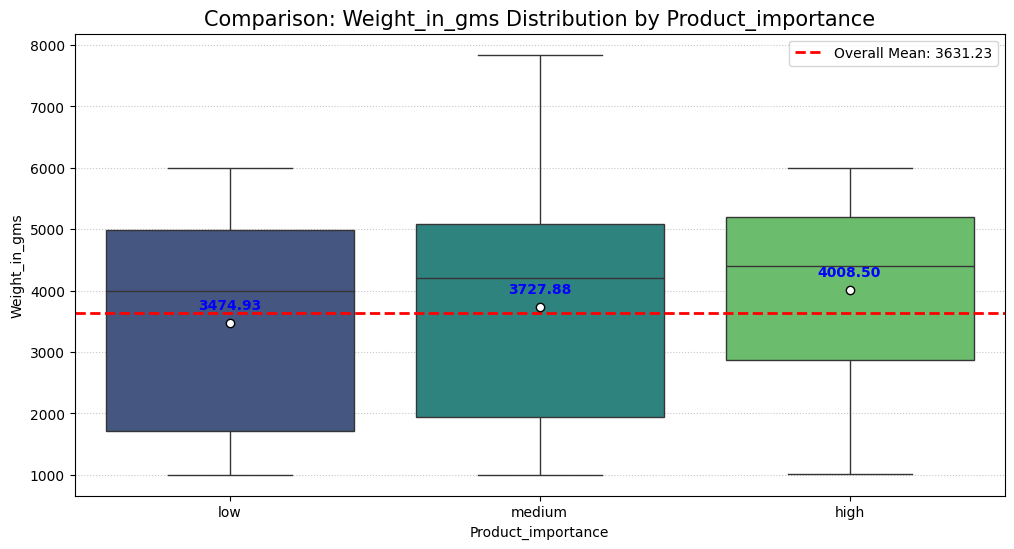

In [36]:
summarize_numeric_with_plots(train_df, 'Product_importance', num_cols, threshold=0.1)

In [37]:
summarize_categorical_with_plots(train_df, 'Gender', cat_cols, threshold=5.0)

[✅ 이상치 없음] 'Warehouse_block': 모든 Gender에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Mode_of_Shipment': 모든 Gender에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Customer_care_calls': 모든 Gender에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Customer_rating': 모든 Gender에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Prior_purchases': 모든 Gender에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Product_importance': 모든 Gender에서 고른 분포를 보입니다.


In [38]:
summarize_numeric_with_plots(train_df, 'Gender', num_cols, threshold=0.1)

[✅ 통과] 'Cost_of_the_Product': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Discount_offered': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Weight_in_gms': 그룹별 평균 차이가 미미합니다.


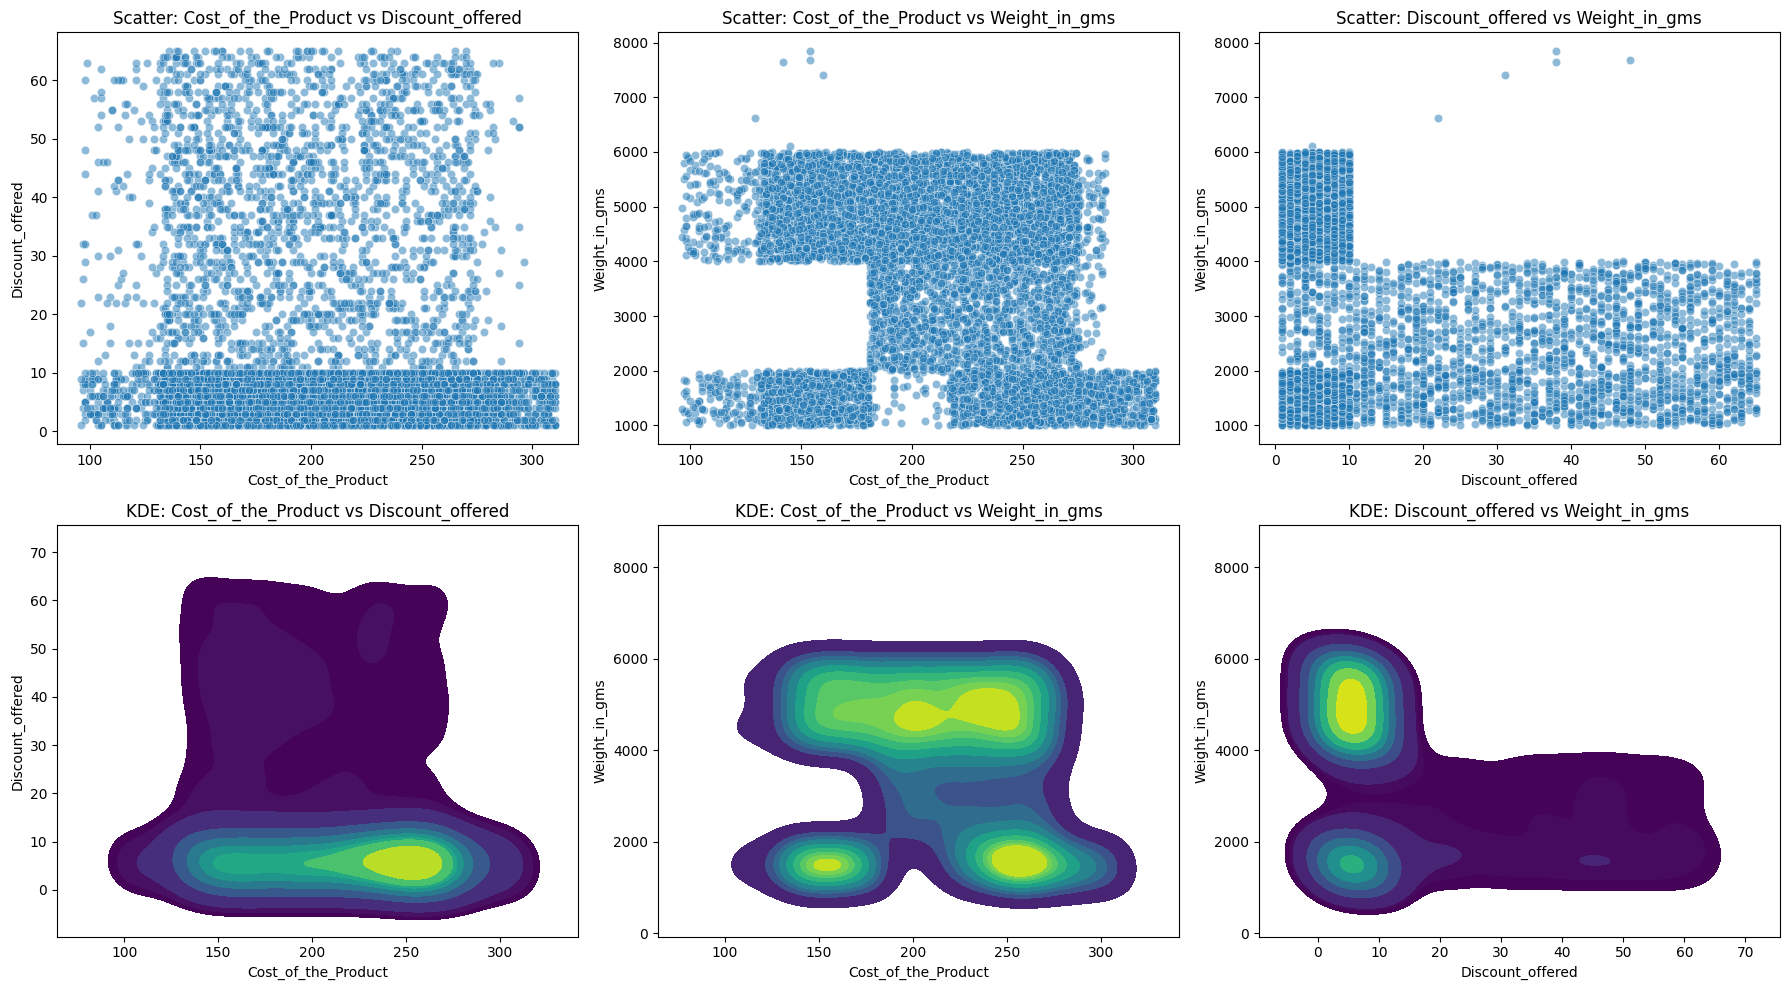

In [39]:
# 1행 3열의 레이아웃 설정
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- 첫 번째 열: 가격(Price) vs 할인액(Discount) ---
# 1행: 산점도
sns.scatterplot(data=train_df, x=num_cols[0], y=num_cols[1], ax=axes[0, 0], alpha=0.5)
axes[0, 0].set_title(f'Scatter: {num_cols[0]} vs {num_cols[1]}')
# 2행: KDE Plot
sns.kdeplot(data=train_df, x=num_cols[0], y=num_cols[1], ax=axes[1, 0], fill=True, cmap='viridis')
axes[1, 0].set_title(f'KDE: {num_cols[0]} vs {num_cols[1]}')
# --- 두 번째 열: 가격(Price) vs 무게(Weight) ---
# 1행: 산점도
sns.scatterplot(data=train_df, x=num_cols[0], y=num_cols[2], ax=axes[0, 1], alpha=0.5)
axes[0, 1].set_title(f'Scatter: {num_cols[0]} vs {num_cols[2]}')
# 2행: KDE Plot
sns.kdeplot(data=train_df, x=num_cols[0], y=num_cols[2], ax=axes[1, 1], fill=True, cmap='viridis')
axes[1, 1].set_title(f'KDE: {num_cols[0]} vs {num_cols[2]}')
# --- 세 번째 열: 할인액(Discount) vs 무게(Weight) ---
# 1행: 산점도
sns.scatterplot(data=train_df, x=num_cols[1], y=num_cols[2], ax=axes[0, 2], alpha=0.5)
axes[0, 2].set_title(f'Scatter: {num_cols[1]} vs {num_cols[2]}')
# 2행: KDE Plot
sns.kdeplot(data=train_df, x=num_cols[1], y=num_cols[2], ax=axes[1, 2], fill=True, cmap='viridis')
axes[1, 2].set_title(f'KDE: {num_cols[1]} vs {num_cols[2]}')
# 전체 레이아웃 조정
plt.tight_layout()
plt.show()

## 데이터 비교분석 결과 해석

### 1. Warehouse_block
* A, B, C, D, F 총 5개동
* F동을 제외하고 균일한 비중. F동은 타 동의 2배
* 각 동에 따른 다른 특성의 분포 차이 없음 - 무게, 가격, 운송 수단에 따른 영향이 없다
* 하나의 큰 창고에서 운송일 등 현재 데이터에 없는 기준으로 각 동에 분류하는 것으로 추정


In [40]:
train_df['Warehouse_block'].value_counts()

Warehouse_block
F    2910
B    1487
D    1470
A    1468
C    1464
Name: count, dtype: int64

### 2. Mode_of_Shipment
* Ship, Flight, Road 세 개의 운송 수단
* Ship의 비중이 압도적
* 운송수단에 따른 다른 특성의 분포 차이 없음
    -> 실제로는 가격/무게/부피에 따라 운송수단이 선택되는것을 고려한다면 이상한 데이터.

In [41]:
train_df['Mode_of_Shipment'].value_counts()

Mode_of_Shipment
Ship      5981
Flight    1420
Road      1398
Name: count, dtype: int64

### 3. Prior_purchases
* 2, 3, 4, 5, 6+ 의 구매횟수. 5개 종류
* 지연율은 중간지점은 4, 5에서 점점 낮아지다 6이후에서 다시 증가하는 형태
* 'Prior_purchases'의 분포 확인 결과 4 이후에 급격한 하락.
    -> 잦은 지연에 고객들의 이탈이 발생했을 가능성


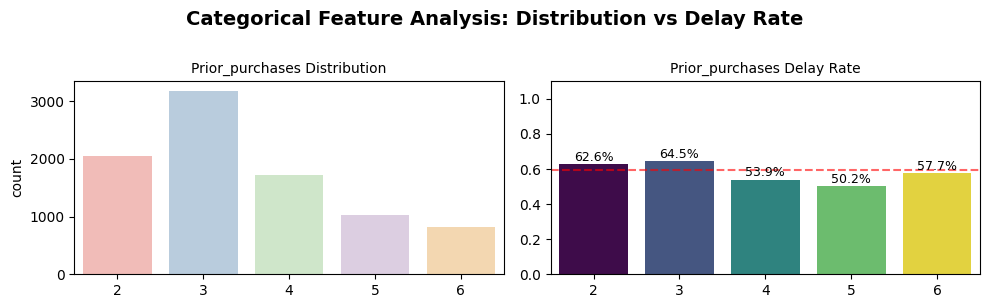

In [42]:
# 6이상의 구매횟수 통합한 버전의 시각화
plot_categorical_analysis(train_df, ['Prior_purchases'], target)

#### 다른 특성과의 관계
##### 'Prior_purchases'와 'Product_importance'
* 구매횟수 2~5: 낮은 중요도의 비중이 상승
* 구매횟수 6: 높은 중요도와 중간 중요도의 비중 급격한 상승
* 가설1: 단골고객(구매횟수>5)에게 중요도가 높은 상품을 구매할 요인이 있나?

가설 1

In [43]:
copy_df = train_df.copy()
copy_df['is_loyal'] = (copy_df['Prior_purchases'] > 5).astype(int)
copy_df['is_loyal'].value_counts()

# 분석을 위해 copy_df의 'Product_importance'을 레이블링
importance_map = {'low': 0, 'medium': 1, 'high': 2}
copy_df['Product_importance'] = copy_df['Product_importance'].map(importance_map).astype(int)

# 분석을 위해 추가로 '할인율' 생성
copy_df['Discount_rate'] = (copy_df['Discount_offered'] / copy_df['Cost_of_the_Product'])*100

In [44]:
copy_df.groupby('is_loyal')[['Product_importance', 'Cost_of_the_Product', 'Discount_offered','Discount_rate', target]].agg(['mean', 'median'])

Product_importance        Cost_of_the_Product         \
                       mean median                mean median   
is_loyal                                                        
0                  0.594557    1.0          210.135691  213.0   
1                  0.741818    1.0          211.145455  221.0   

         Discount_offered        Discount_rate           Reached.on.Time_Y.N  \
                     mean median          mean    median                mean   
is_loyal                                                                       
0               13.482192    7.0      7.074021  3.333333            0.598696   
1               12.253333    7.0      6.439064  3.355705            0.576970   

                 
         median  
is_loyal         
0           1.0  
1           1.0

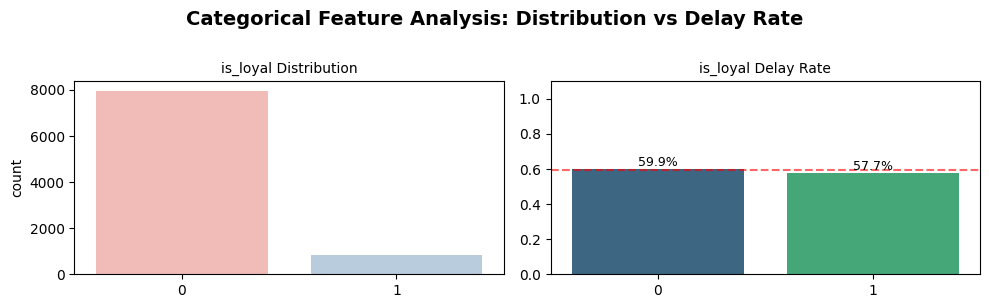

In [45]:
plot_categorical_analysis(copy_df,['is_loyal'], target)

결론
* 'is_loyal'에게 제공되는 유인사항 없음.
* 가격 혜택(할인율) 또는 배송 우대와 같은 혜택이 없음을 확인.
* 지연율에 약 2%의 차이만을 발견 -> 모델학습에 도움을 주지 않을 것으로 판단.

### 4. Customer_rating
* 1, 2, 3, 4, 5 총 5개 등급
* 등급 간 균일한 비중과 지연율을 보임(최대 3.2%의 차이).
* 지연율과의 경향성, 상관관계 없음
* 각 등급에 따른 다른 특성의 분포 차이 없음
* 현재 데이터에 없는 기준(예를 들어 물품에 대한 만족도)이 적용된 등급으로 추정


### 5. Gender

In [46]:
train_df['Product_importance'].value_counts(normalize=True)

Product_importance
low       0.478918
medium    0.433799
high      0.087283
Name: proportion, dtype: float64

### 6. 'Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms'
* Discount_offered와 Discount_offered는 구간별 지연율의 변화가 확연한 곳이 존재.
* 더 자세한 분석을 위해 구간을 나눠 수치 분석.
* 생성 가능한 파생변수 목록
    1. 세 데이터의 범주화
    2. 할인율: 1-(discount/cost)
    3. 할인가: cost-discount
    4. 무게당 가격: cost/weight


구간별 시각화 분석

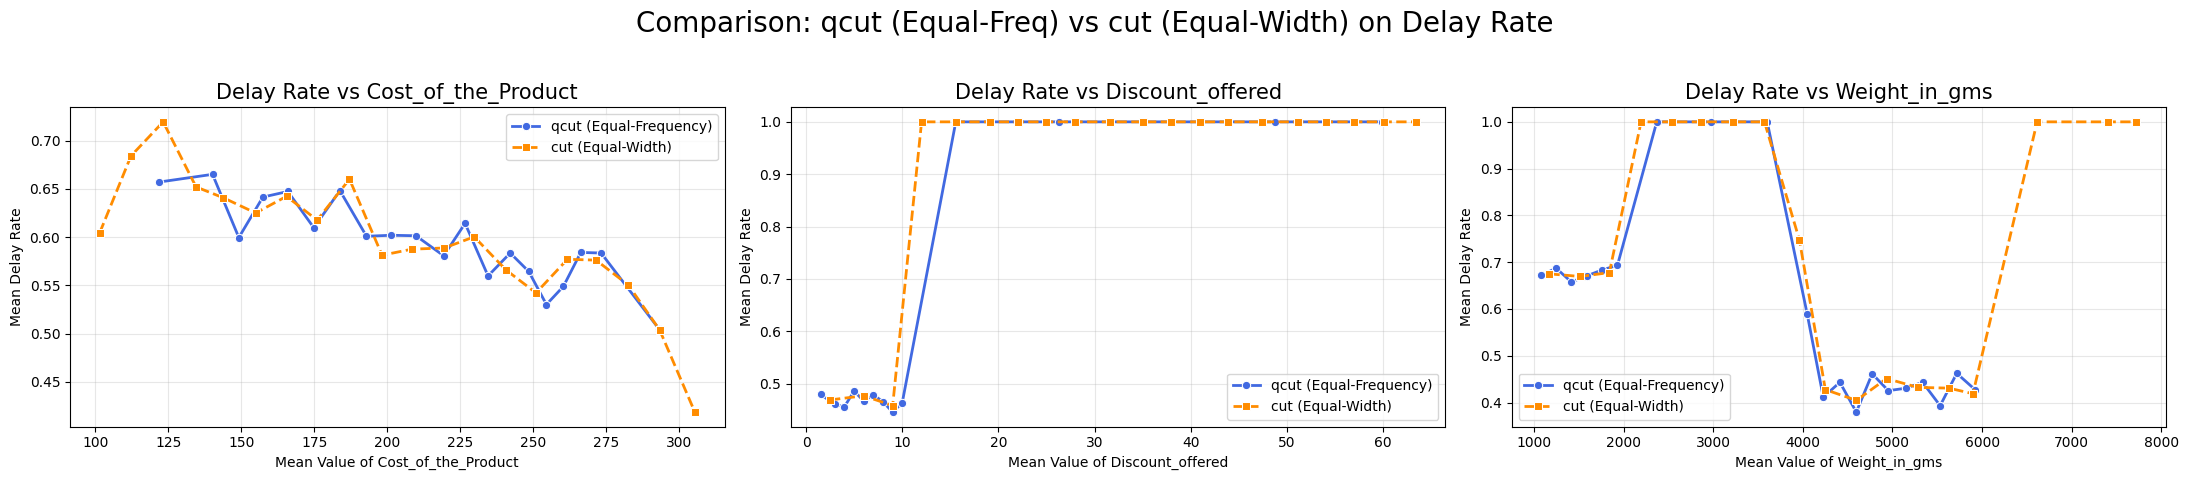

In [47]:
# 1. 분석할 수치형 변수 리스트
features = ['Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms']

# 2. 서브플롯 설정 (1행 3열)
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
fig.suptitle('Comparison: qcut (Equal-Freq) vs cut (Equal-Width) on Delay Rate', fontsize=20)

for i, col in enumerate(features):
    temp_df = copy_df.copy()
    
    # --- A. qcut (데이터 개수 균등) 계산 ---
    temp_df['qcut_Bin'] = pd.qcut(temp_df[col], q=20, duplicates='drop')
    qcut_stats = temp_df.groupby('qcut_Bin', observed=False).agg({col: 'mean', target: 'mean'}).dropna()
    
    # --- B. cut (수치 거리 균등) 계산 ---
    temp_df['cut_Bin'] = pd.cut(temp_df[col], bins=20)
    cut_stats = temp_df.groupby('cut_Bin', observed=False).agg({col: 'mean', target: 'mean'}).dropna()
    
    # --- 시각화 ---
    # 1. qcut 라인 (파란색)
    sns.lineplot(x=qcut_stats[col], y=qcut_stats[target], marker='o', 
                 ax=axes[i], label='qcut (Equal-Frequency)', color='royalblue', linewidth=2)
    
    # 2. cut 라인 (주황색)
    sns.lineplot(x=cut_stats[col], y=cut_stats[target], marker='s', 
                 ax=axes[i], label='cut (Equal-Width)', color='darkorange', linewidth=2, linestyle='--')
    
    axes[i].set_title(f'Delay Rate vs {col}', fontsize=15)
    axes[i].set_xlabel(f'Mean Value of {col}')
    axes[i].set_ylabel('Mean Delay Rate')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

* cost: 가격의 증가에 따라 지연율이 감소하는 우하향 그래프. 범주 전환 불필요
* discount: 10을 초과하는 상품은 지연율 100%. 범주를 나누고 10 이하를 상세 분석
* weight: 2000~4000의 지연율 높은구간, 6000 이후의 표본은 몇인지 조사 필요

1. discount

In [48]:
# 할인액 > 10인 구간에서 지연율 
print(copy_df.loc[copy_df['Discount_offered']==10][target].mean())
print(copy_df.loc[copy_df['Discount_offered']>10][target].mean())

0.4632352941176471
1.0


In [49]:
# 할인액 10 이하 구간의 지연율은 비슷하다는 것을 발견.
copy_df.groupby('Discount_offered')[target].mean().head(10)

Discount_offered
1     0.480061
2     0.479256
3     0.460366
4     0.456325
5     0.485981
6     0.467057
7     0.478593
8     0.465857
9     0.445906
10    0.463235
Name: Reached.on.Time_Y.N, dtype: float64

In [50]:
# 'Discount_group' 생성
copy_df['Discount_group'] = (copy_df['Discount_offered'] > 10).astype(int)
copy_df['Discount_group'].value_counts()

Discount_group
0    6673
1    2126
Name: count, dtype: int64

2. weight

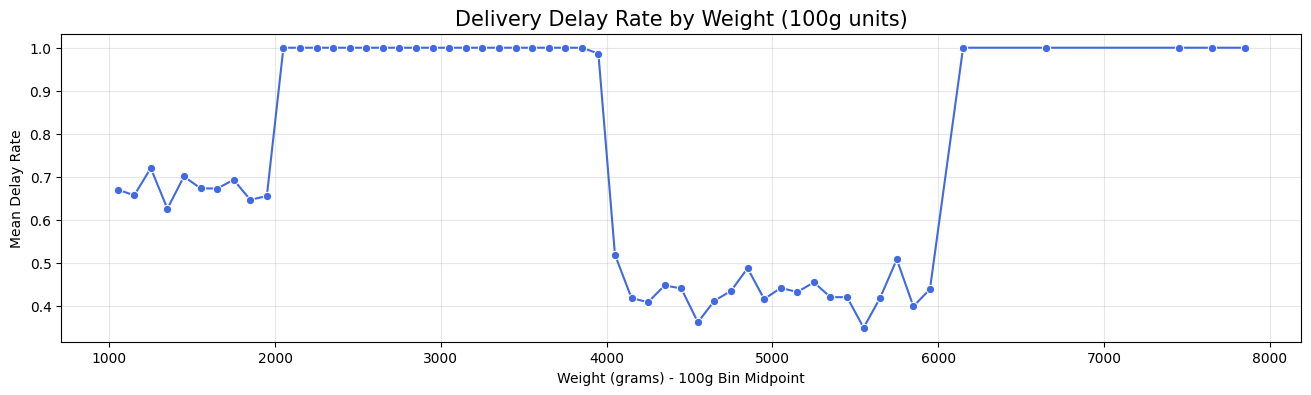

In [51]:
# 세밀한 분석을 위해 100 단위로 나누어 시각화

# 1. 100단위로 구간(bins) 생성
bins_100 = list(range(1000, 8001, 100))
copy_df['Weight_Bin_100'] = pd.cut(copy_df['Weight_in_gms'], bins=bins_100)

# 2. X축에 표시할 값을 구간의 '중간값(mid)'으로 변환 (숫자형으로 시각화하기 위함)
copy_df['Weight_Bin_Mid'] = copy_df['Weight_Bin_100'].apply(lambda x: x.mid if pd.notnull(x) else None).astype(float)

# 3. 시각화
plt.figure(figsize=(16, 4))
sns.lineplot(data=copy_df, x='Weight_Bin_Mid', y=target, marker='o', errorbar=None, color='royalblue')
plt.title('Delivery Delay Rate by Weight (100g units)', fontsize=15)
plt.xlabel('Weight (grams) - 100g Bin Midpoint')
plt.ylabel('Mean Delay Rate')
plt.grid(True, alpha=0.3)
plt.show()

* 무게 6000 이상의 데이터는 100%의 지연율을 보인다.
* 데이터가 너무 적어 이상치일 가능성이 있지만, 2000을 단위로 지연율이 변화하는 것으로 보아 2000~4000의 '위험' 존에 묶기로 하자.
* 무게 구간을 지연율이 낮은 순서부터 1, 2, 3으로 맵핑

In [52]:
# 조건 리스트 정의
conditions = [
    (copy_df['Weight_in_gms'] >= 4000) & (copy_df['Weight_in_gms'] < 6000), 
    (copy_df['Weight_in_gms'] >= 0) & (copy_df['Weight_in_gms'] < 2000)     
]
# 해당 조건에 대응하는 값 리스트
choices = [0, 1]
# 위의 조건들에 해당하지 않는 나머지(2000~4000 및 6000 이상)는 default 값 2으로 할당
copy_df['Weight_Category'] = np.select(conditions, choices, default=2)

3. 할인율 Discount_rate
    

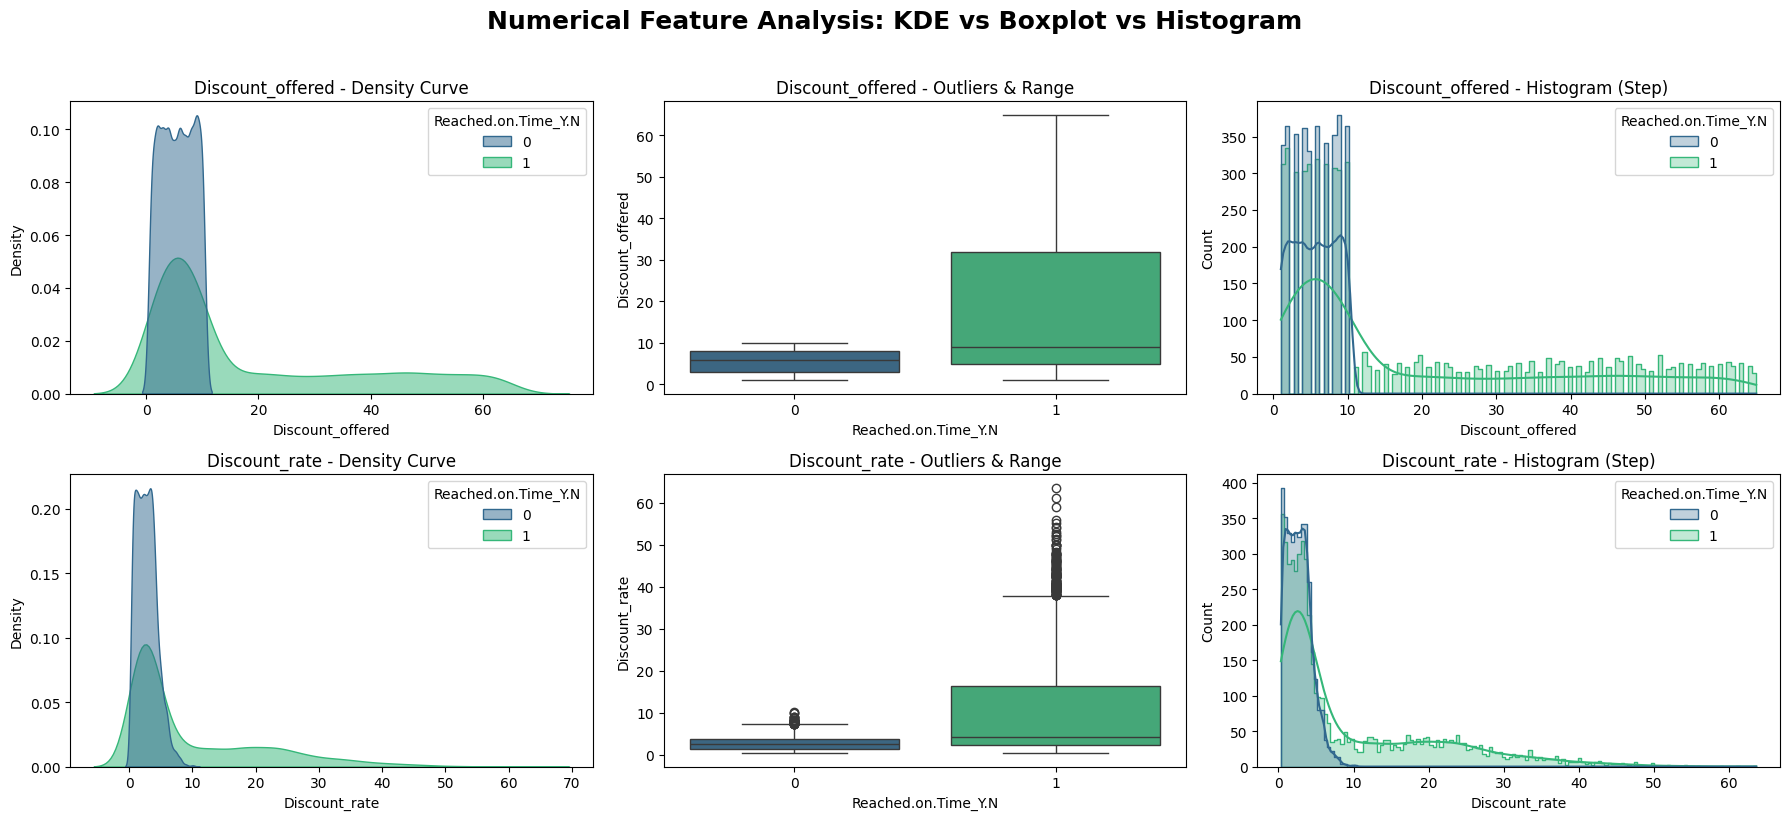

Discount_offered    0.398429
Discount_rate       0.381533
Name: Reached.on.Time_Y.N, dtype: float64


In [53]:
# 할인액과 할인율 비교
plot_numeric_analysis(copy_df, ['Discount_offered', 'Discount_rate'], target)
print(copy_df[['Discount_offered', 'Discount_rate', target]].corr()[target].drop(target))

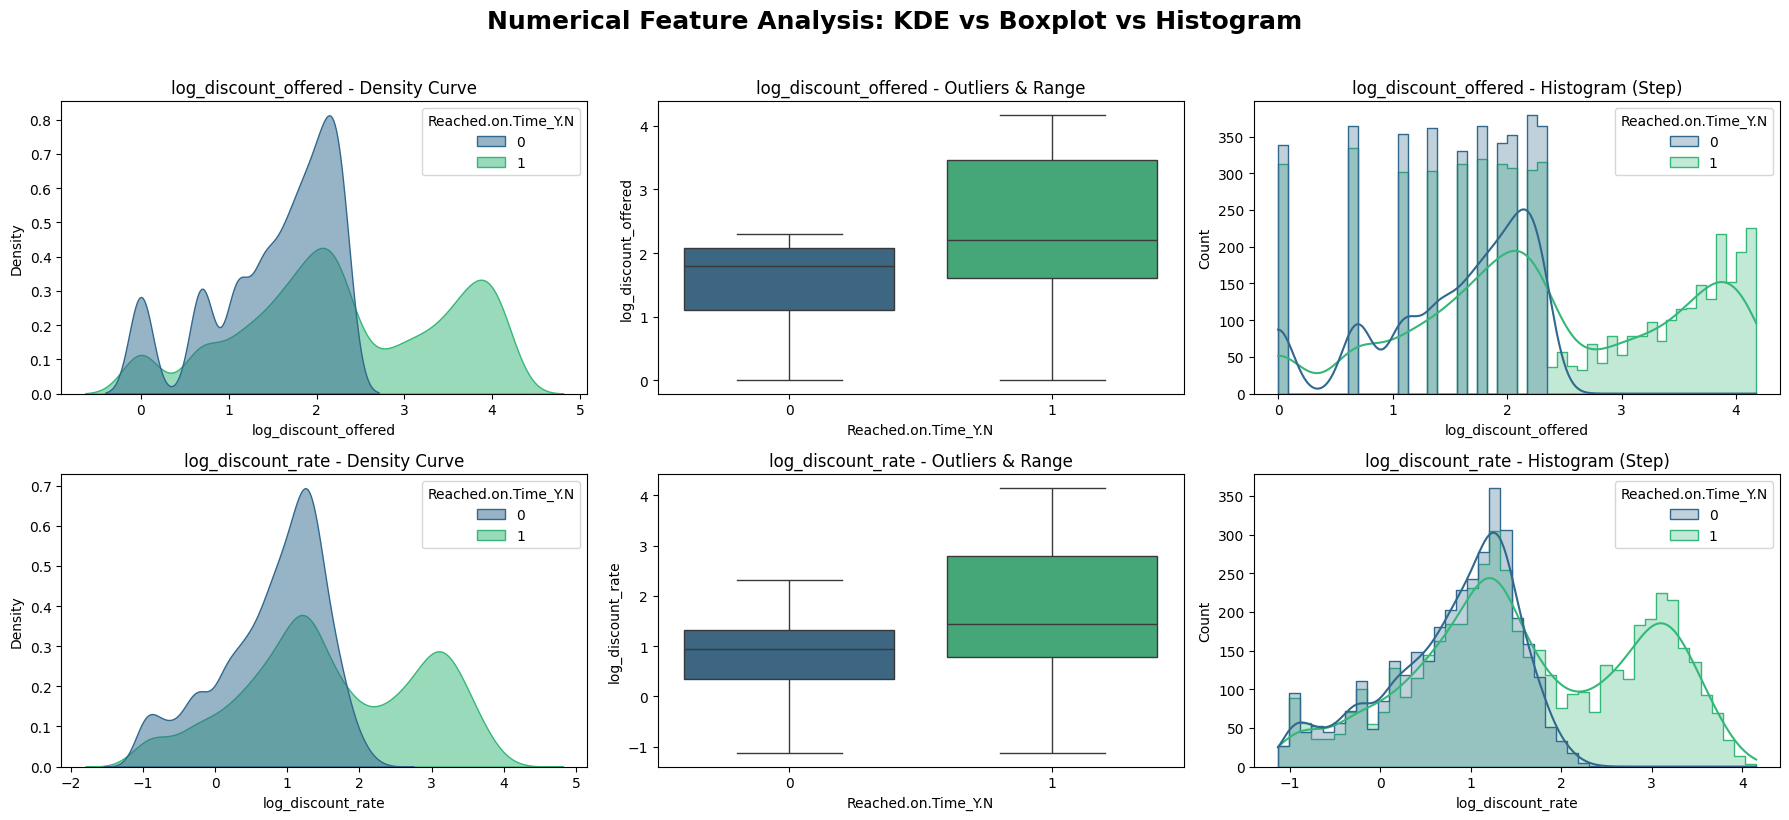

log_discount_offered    0.365141
log_discount_rate       0.362631
Name: Reached.on.Time_Y.N, dtype: float64


In [54]:
copy_df['log_discount_offered'] = np.log(copy_df['Discount_offered'])
copy_df['log_discount_rate'] = np.log(copy_df['Discount_rate'])

plot_numeric_analysis(copy_df, ['log_discount_offered', 'log_discount_rate'], target)
print(copy_df[['log_discount_offered', 'log_discount_rate', target]].corr()[target].drop(target))

Discount_offered의 상관계수가 가장 높다.

4. 할인가 Discounted_price

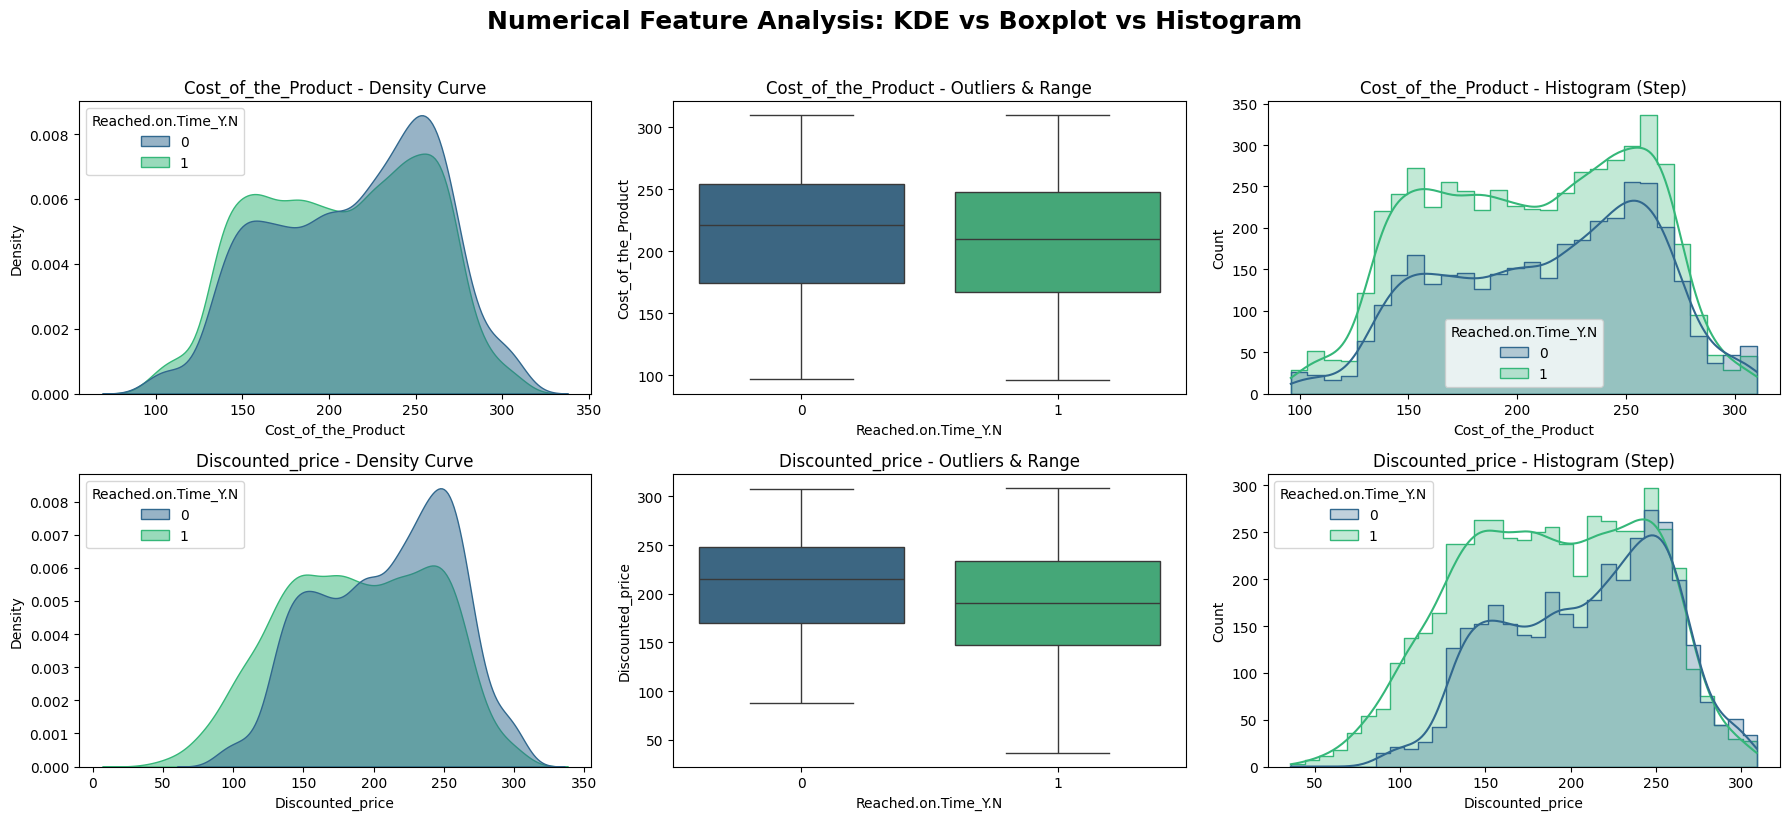

Discounted_price      -0.189176
Cost_of_the_Product   -0.073743
Name: Reached.on.Time_Y.N, dtype: float64


In [55]:
# 원가와 실구매가 비교 -> 실구매가가 더 나은 지표
copy_df['Discounted_price'] = copy_df['Cost_of_the_Product'] - copy_df['Discount_offered']
plot_numeric_analysis(copy_df, ['Cost_of_the_Product', 'Discounted_price'], target)
print(copy_df[['Discounted_price', 'Cost_of_the_Product', target]].corr()[target].drop(target))

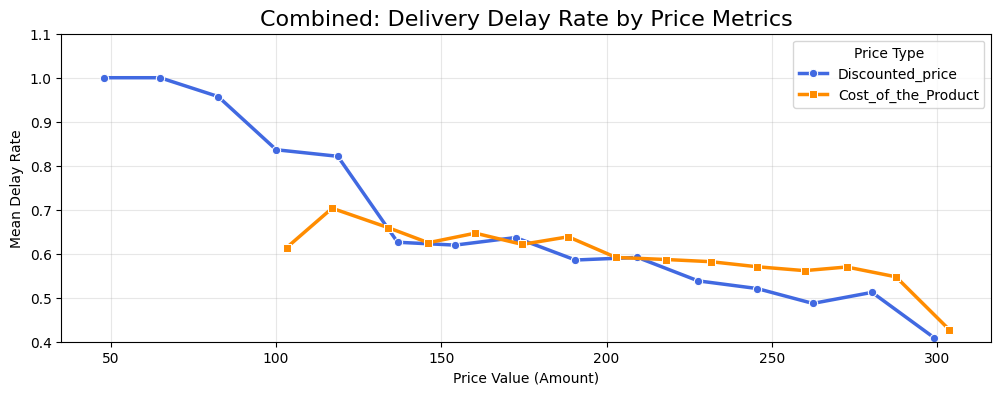

In [56]:
plt.figure(figsize=(12, 4))

# 분석할 두 타겟 변수
features = ['Discounted_price', 'Cost_of_the_Product']
colors = ['royalblue', 'darkorange']
markers = ['o', 's']

for col, color, marker in zip(features, colors, markers):
    temp_df = copy_df.copy()
    
    # 15개 정도로 더 세밀하게 구간 분할
    temp_df['Bin'] = pd.cut(temp_df[col], bins=15)
    
    # 구간별 평균 및 지연율 계산
    bin_stats = temp_df.groupby('Bin', observed=False).agg({
        col: 'mean',
        target: 'mean'
    }).dropna()
    
    # 하나의 axes에 겹쳐서 그리기
    sns.lineplot(x=bin_stats[col], y=bin_stats[target], marker=marker, 
                 label=col, color=color, linewidth=2.5)

plt.title('Combined: Delivery Delay Rate by Price Metrics', fontsize=16)
plt.xlabel('Price Value (Amount)')
plt.ylabel('Mean Delay Rate')
plt.legend(title='Price Type')
plt.grid(True, alpha=0.3)
plt.ylim(0.4, 1.1) # 변화를 잘 보이게 하기 위해 범위를 조절

plt.show()

5. 무게당 가격 price_per_weight

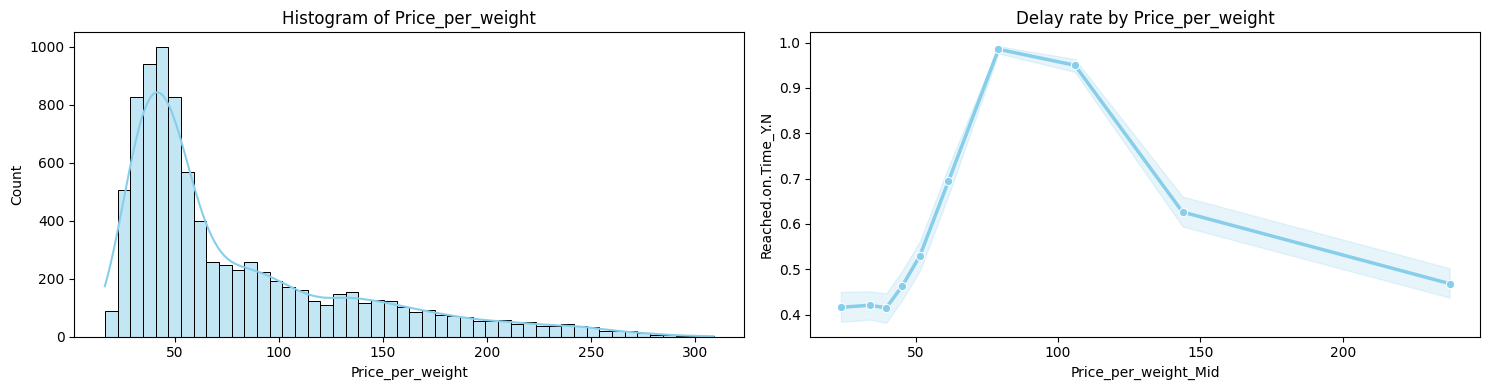

In [57]:
# 무게를 kg으로 변환하고 무게당 가격을 구한다.
copy_df['Price_per_weight'] = copy_df['Cost_of_the_Product'] / (copy_df['Weight_in_gms'] / 1000)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# 2. 데이터를 10개 구간으로 나누기 (데이터 분포 중심의 qcut 사용)
copy_df['Price_per_weight_Bin'] = pd.qcut(copy_df['Price_per_weight'], q=10, duplicates='drop')
# 3. 구간별 중간값(X축용) 계산
copy_df['Price_per_weight_Mid'] = copy_df['Price_per_weight_Bin'].apply(lambda x: x.mid).astype(float)

# [왼쪽] 히스토그램 + KDE (전체적인 분포 모양)
sns.histplot(copy_df['Price_per_weight'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Histogram of Price_per_weight')

# [오른쪽] 히스토그램 (이상치 및 사분위수 확인)
sns.lineplot(data=copy_df, x='Price_per_weight_Mid', y=target, ax=axes[1], marker='o', color='skyblue', linewidth=2.5)
axes[1].set_title('Delay rate by Price_per_weight')

plt.tight_layout()
plt.show()

In [58]:
corr_val = copy_df[['Price_per_weight', target]].corr().iloc[0, 1]
print(f"📊 상관계수 (Price_per_weight vs Target): {corr_val:.4f}")

📊 상관계수 (Price_per_weight vs Target): 0.0801


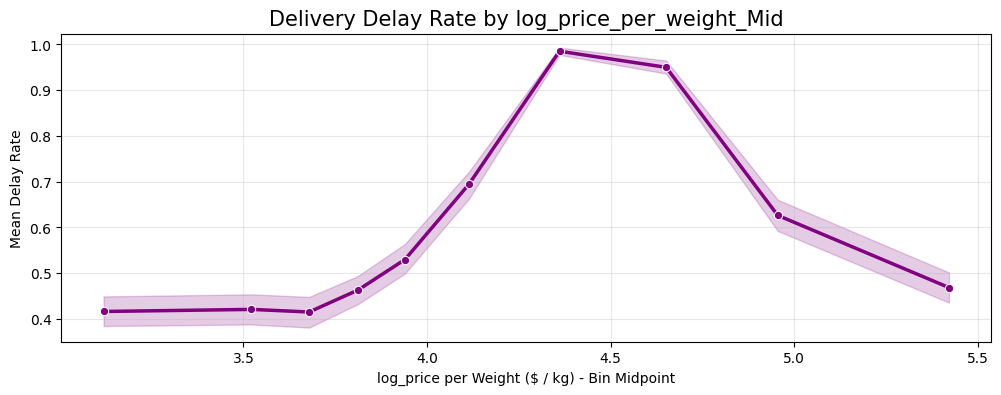

In [59]:
# Price_per_weight의 분포가 편향되었기 때문에 log를 취한다
copy_df['log_price_per_weight'] = np.log(copy_df['Price_per_weight'])

# 데이터를 10개 구간으로 나누기 (데이터 분포 중심의 qcut 사용)
copy_df['log_price_per_weight_Bin'] = pd.qcut(copy_df['log_price_per_weight'], q=10, duplicates='drop')
# 구간별 중간값(X축용) 계산
copy_df['log_price_per_weight_Mid'] = copy_df['log_price_per_weight_Bin'].apply(lambda x: x.mid).astype(float)
# 시각화
plt.figure(figsize=(12, 4))
sns.lineplot(data=copy_df, x='log_price_per_weight_Mid', y=target, marker='o', color='purple', linewidth=2.5)
plt.title('Delivery Delay Rate by log_price_per_weight_Mid', fontsize=15)
plt.xlabel('log_price per Weight ($ / kg) - Bin Midpoint')
plt.ylabel('Mean Delay Rate')
plt.grid(True, alpha=0.3)



In [60]:
corr_val = copy_df[['log_price_per_weight', target]].corr().iloc[0, 1]
print(f"📊 상관계수 (log_price_per_weight vs Target): {corr_val:.4f}")
plt.show()

📊 상관계수 (log_price_per_weight vs Target): 0.1728


새로운 파생변수 'Discount_group', 'Weight_Category', 'Discounted_price', 'log_price_per_weight'를 생성하였다

### 7. Product_importance
* high, medium, low 3개의 등급.
* high의 비중이 8%로 굉장히 적다.
* 중요도 high인 제품의 지연율이 역설적이게도 가장 높다. (지연율 64.8%)


* 가설1: 중요도의 기준은 제품의 중요도가 아닌 다른 기준이 있는가?

가설  검증
1. 중요도에 따라 제품과 관계된 지표가 어떻게 움직이는지 관찰

In [61]:
# 데이터 집계 (평균과 중앙값 모두 계산)
agg_dict = {col: ['mean', 'median'] for col in [
    'Price_per_weight', 'log_price_per_weight', 'Cost_of_the_Product', 
    'Discounted_price', 'Weight_in_gms', 'Discount_offered', 
    'Discount_rate', 'Prior_purchases'
]}
agg_dict['Reached.on.Time_Y.N'] = ['mean']

# 집계 결과 생성
result_table = copy_df.groupby('Product_importance').agg(agg_dict)


display(result_table.style.background_gradient(cmap='Blues').format("{:.2f}"))

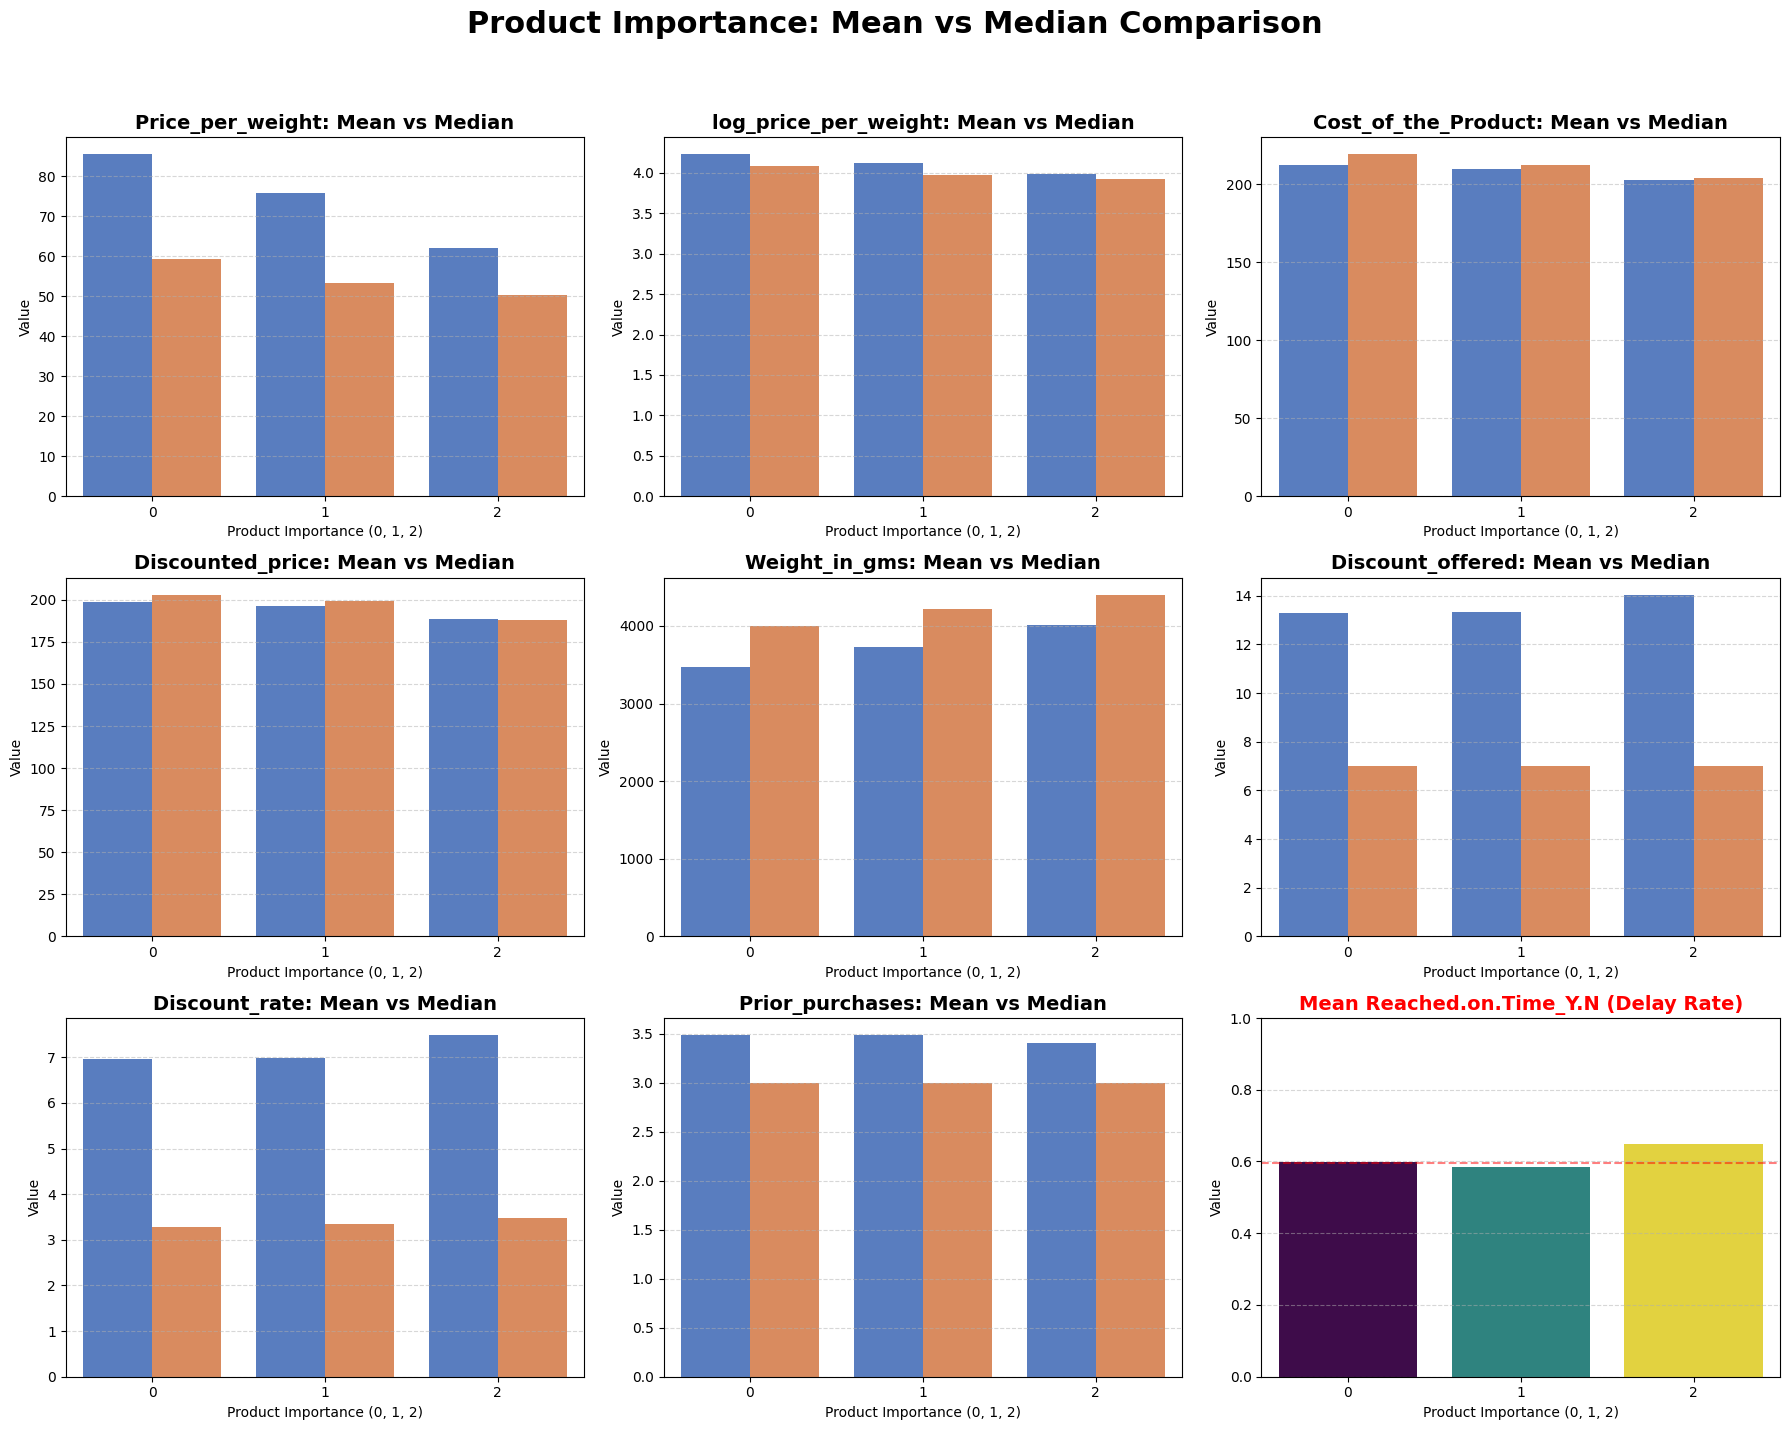

In [64]:
# 집계 및 멀티인덱스 칼럼 평탄화
result = copy_df.groupby('Product_importance').agg(agg_dict)
result.columns = [f"{col}_{stat}" for col, stat in result.columns]

# 시각화를 위한 변수 설정
cols_base = [
    'Price_per_weight', 'log_price_per_weight', 'Cost_of_the_Product', 
    'Discounted_price', 'Weight_in_gms', 'Discount_offered', 
    'Discount_rate', 'Prior_purchases', 'Reached.on.Time_Y.N'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Product Importance: Mean vs Median Comparison', fontsize=22, fontweight='bold', y=0.98)

# 범례 핸들과 라벨을 저장할 변수
handles, labels = None, None

for i, col in enumerate(cols_base):
    row, col_idx = divmod(i, 3)
    ax = axes[row, col_idx]
    
    if col == 'Reached.on.Time_Y.N':
        # 지연율: 단일 지표이므로 범례 불필요
        sns.barplot(data=copy_df, x='Product_importance', y=col, ax=ax, hue='Product_importance', palette='viridis', legend=False, errorbar=None)
        ax.set_title(f'Mean {col} (Delay Rate)', fontsize=14, fontweight='bold', color='red')
        ax.axhline(copy_df[col].mean(), color='red', linestyle='--', alpha=0.5)
        ax.set_ylim(0, 1)
    else:
        # 평균과 중앙값 비교 데이터 구성
        plot_df = result[[f"{col}_mean", f"{col}_median"]].reset_index().melt(
            id_vars='Product_importance', value_vars=[f"{col}_mean", f"{col}_median"],
            var_name='Stat', value_name='Value'
        )
        plot_df['Stat'] = plot_df['Stat'].str.replace(f"{col}_", "")
        
        # legend=False를 추가하여 개별 subplot의 범례를 제거
        sns.barplot(data=plot_df, x='Product_importance', y='Value', hue='Stat', ax=ax, palette='muted', legend=False)
        ax.set_title(f'{col}: Mean vs Median', fontsize=14, fontweight='bold')

        # 첫 번째 대상 그래프에서만 범례 정보를 추출
        if handles is None:
            handles, labels = ax.get_legend_handles_labels()

    ax.set_xlabel('Product Importance (0, 1, 2)')
    ax.set_ylabel('Value')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# 전체 피규어의 우측 상단에 범례 추가
if handles:
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.95, 0.95), title='Statistics', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

importance 분석 결론
* 무게 대비 가격이 싼 물품을 'high'에, 비싼 물품을 'low'에 배정
* 그 외의 할인액 등의 가격적인 측면은 영향력 미미

결론: Product_importance는 관리 후순위 지표

### 8. Customer_care_calls
* 2~7의 데이터가 있으나 너무 적은 데이터는 통합
* 3, 4, 5, 6회의 전화 문의
* 문의가 많아질수록 지연율이 적어짐을 확인
* 문의 횟수의 최소값이 2라는 점은 배송이 지연되지 않았을 때의 수치라고 하기에는 이상함
* 가설 1: 이 데이터는 현재 배송에 대한 문의가 아니라, 지금까지 누적되어온 횟수이다.
* 가설 2: 배송에 대한 상태를 알리기 위해 회사측이 발송한 안내 횟수이다.
    - 즉, 회사에서 특별 관리하는 화물을 알리는 지표이다.


가설 1 검증
* Customer_care_call이 과거부터 누적되어온 수치라면, 구매횟수가 증가할수록 call의 횟수도 증가할것이다.

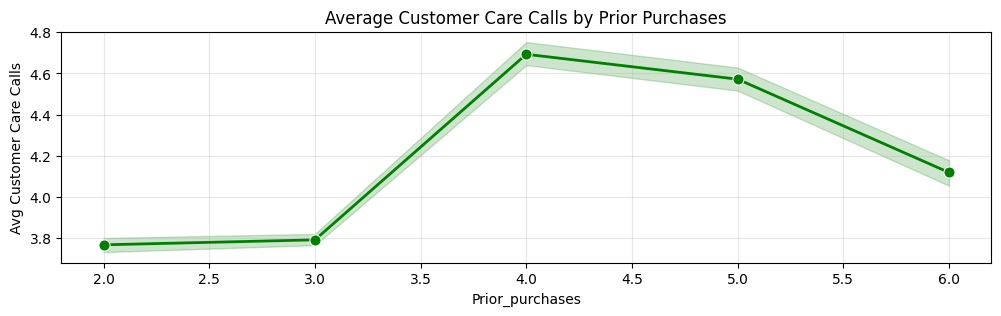

📊 두 변수의 상관계수: 0.2559


In [ ]:
# 과거 구매 횟수에 따른 문의 횟수의 증가 시각화

plt.figure(figsize=(12, 3))

# 1. 선 그래프 (Line Plot): 각 Prior_purchases 별 평균 Call 횟수의 변화 흐름
# 그림자(shade) 구간은 신뢰구간(95% confidence interval)입니다.
sns.lineplot(data=train_df, x='Prior_purchases', y='Customer_care_calls', 
             marker='o', markersize=8, linewidth=2, color='green')

plt.title('Average Customer Care Calls by Prior Purchases')
plt.ylabel('Avg Customer Care Calls')
plt.grid(True, alpha=0.3)
plt.show()

# 2. 수학적 상관계수 계산
corr = train_df[['Prior_purchases', 'Customer_care_calls']].corr().iloc[0, 1]
print(f"📊 두 변수의 상관계수: {corr:.4f}")

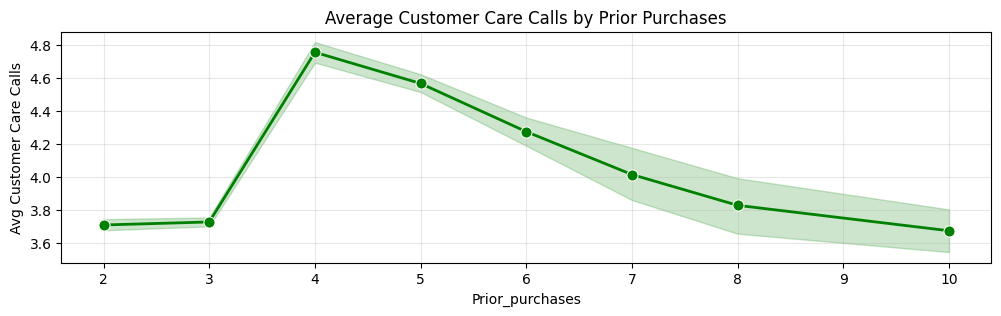

📊 두 변수의 상관계수: 0.1808


In [ ]:
plt.figure(figsize=(12, 3))

# 1. 선 그래프 (Line Plot): 각 Prior_purchases 별 평균 Call 횟수의 변화 흐름
# 그림자(shade) 구간은 신뢰구간(95% confidence interval)입니다.
sns.lineplot(data=df, x='Prior_purchases', y='Customer_care_calls', 
             marker='o', markersize=8, linewidth=2, color='green')

plt.title('Average Customer Care Calls by Prior Purchases')
plt.ylabel('Avg Customer Care Calls')
plt.grid(True, alpha=0.3)
plt.show()

# 2. 수학적 상관계수 계산
corr = df[['Prior_purchases', 'Customer_care_calls']].corr().iloc[0, 1]
print(f"📊 두 변수의 상관계수: {corr:.4f}")

가설 검증 해석
* 가공 전/후의 데이터가 모두 4 이후에서 감소하는 모양
* 상관관계도 가공 전 0.18, 가공 후 0.26
* 이는 2가지 가능한 결론
    1. 누적된 기록이 아닌, 해당 배송에 대한 기록이다. -> 정시 배송에도 문의횟수 2는 설명이 안됨
    2. 해당 회사에서의 구매 경험이 많은 사람은 지연에 큰 신경을 쓰지 않는다.

가설 2 검증
* 회사의 특별 관리 화물 지표임을 증명할 방안
    1. 화물 관리 레벨(Management_level) =  관리 지표(call) / 배송 난이도(무게) 라고 가정
    2. 'Management_level'에 따른 지연율 차이. 반비례할것이다.
    3. 과거 구매 기록에 따른 연락 횟수 변화(vip 우대 시스템의 가능성) -> 양의 상관관계가 있음을 확인했다.

In [ ]:
copy_df['Cost_of_the_Product'].describe()

count    8799.000000
mean      210.230367
std        48.051317
min        96.000000
25%       170.000000
50%       214.000000
75%       251.000000
max       310.000000
Name: Cost_of_the_Product, dtype: float64

In [ ]:
copy_df = train_df.copy()
# Management_level 생성
copy_df['Management_level'] = copy_df['Customer_care_calls'] / (copy_df['Weight_in_gms'] * (1/1000))
copy_df['Management_level'].describe()

count    8799.000000
mean        1.589630
std         1.218965
min         0.382360
25%         0.725953
50%         1.002004
75%         2.208115
max         5.982054
Name: Management_level, dtype: float64

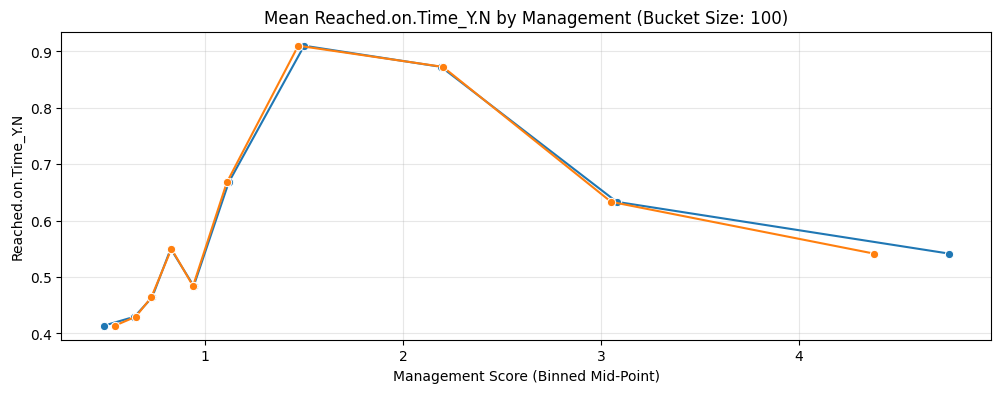

In [ ]:
# Management_level에 따른 지연율의 시각화

# 1. 구간 나누기
copy_df['Management_Bin'] = pd.qcut(copy_df['Management_level'], q=10, duplicates='drop')

# 2. X축에 쓰기 위해 '구간의 대표값'을 축출해서 새로운 수치형 컬럼 생성
# 평균값과 중간값을 둘다 시도
copy_df['Management_Bin_Mid'] = copy_df['Management_Bin'].apply(lambda x: x.mid).astype(float)
copy_df['Management_Bin_Mean'] = copy_df.groupby('Management_Bin', observed=False)['Management_level'].transform('mean')
# 3. 시각화
plt.figure(figsize=(12, 4))
sns.lineplot(data=copy_df, x='Management_Bin_Mid', y=target, marker='o', errorbar=None)
sns.lineplot(data=copy_df, x='Management_Bin_Mean', y=target, marker='o', errorbar=None)


plt.title(f'Mean {target} by Management (Bucket Size: 100)')
plt.xlabel('Management Score (Binned Mid-Point)')
plt.grid(True, alpha=0.3)
plt.show()



In [ ]:
# 상관계수 출력
print(copy_df[['Management_level', target]].corr().iloc[0, 1])
print(copy_df[['Management_Bin_Mid', target]].corr().iloc[0, 1])
print(copy_df[['Management_Bin_Mean', target]].corr().iloc[0, 1])

0.08895321859812041
0.08960076585161934
0.09724723053292866


* 'Management_level'의 일정 구간 이후에는 지연율이 낮아지는 것을 확인. 
* 파생변수로 사용 가능하나, 생성공식의 '배송 난이도'를 무게 외의 사항도 고려하여 새로 도출해볼것.

과거 구매기록에 따른 management_level의 증가 확인

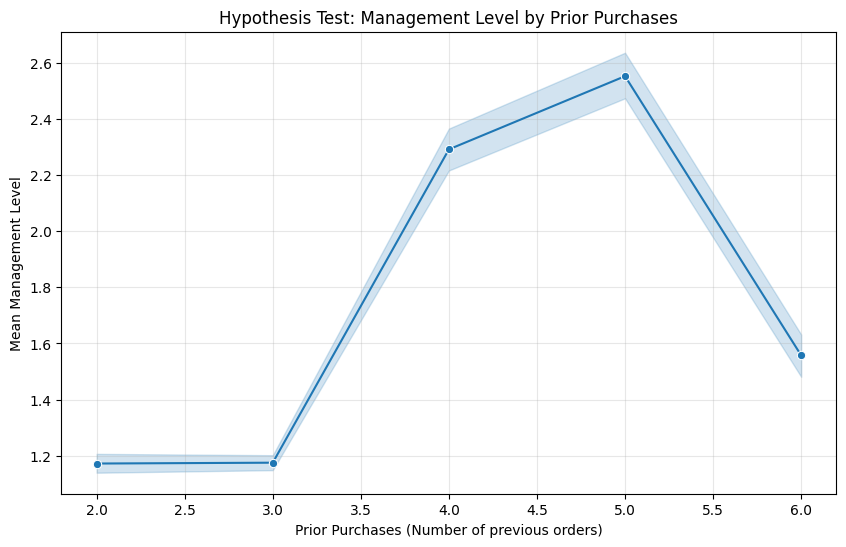

In [ ]:
plt.figure(figsize=(10, 6))

# X축: 독립 변수(원인), Y축: 종속 변수(결과/평균)
sns.lineplot(data=copy_df, x='Prior_purchases', y='Management_level', marker='o')

plt.title('Hypothesis Test: Management Level by Prior Purchases')
plt.xlabel('Prior Purchases (Number of previous orders)')
plt.ylabel('Mean Management Level')
plt.grid(True, alpha=0.3)
plt.show()

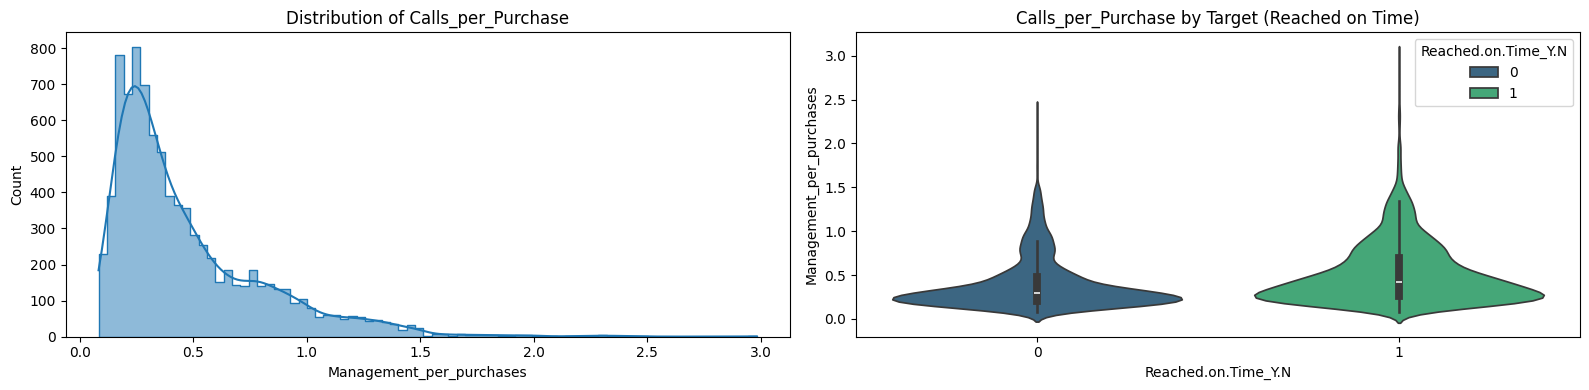

📊 두 변수의 상관계수: 0.1806


In [ ]:
# 'prior purchase'에 따른 'management_level'의 추세
copy_df['Management_per_purchases'] = (copy_df['Management_level'] / copy_df['Prior_purchases'])

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# 1. 왼쪽: Management_per_purchases 전체 분포 (Histogram + KDE)
sns.histplot(data=copy_df, x='Management_per_purchases', kde=True, element="step", ax=axes[0])
axes[0].set_title('Distribution of Calls_per_Purchase')

# 2. 오른쪽: Target(도착 여부)에 따른 Management_per_purchases 분포 차이 (Boxplot)
sns.violinplot(data=copy_df, x=target, y='Management_per_purchases', hue=target, ax=axes[1], palette='viridis')
axes[1].set_title('Management_per_purchases by Target (Reached on Time)')

plt.tight_layout()
plt.show()

corr = copy_df[['Management_per_purchases', target]].corr().iloc[0, 1]
print(f"📊 두 변수의 상관계수: {corr:.4f}")

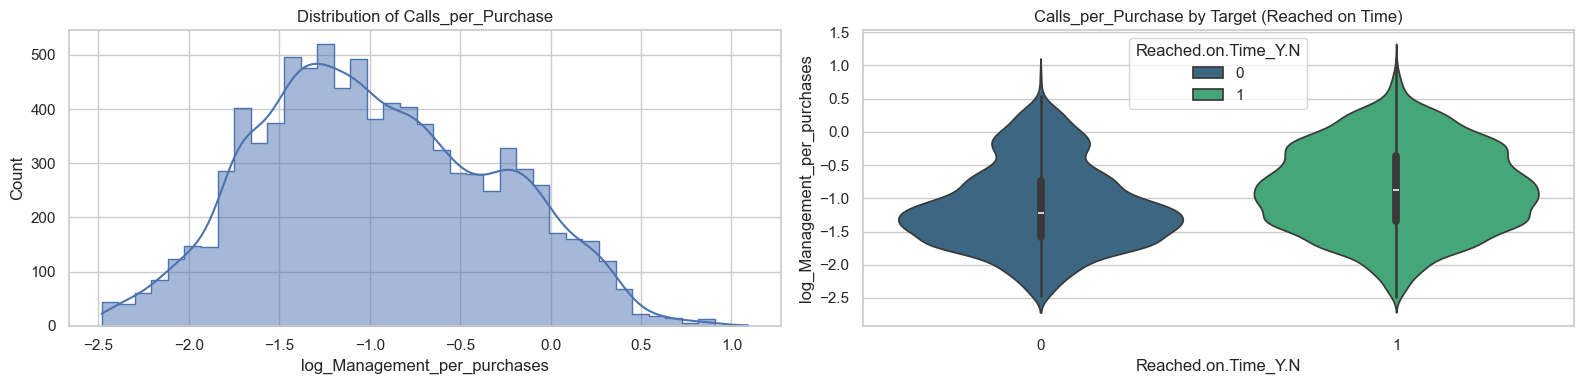

📊 두 변수의 상관계수: 0.2072


In [ ]:
# 'Management_per_purchases'에 로그를 취해 분포 안정화
copy_df['log_Management_per_purchases'] = np.log(copy_df['Management_per_purchases'])

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# 1. 왼쪽: Calls_per_Purchase의 전체 분포 (Histogram + KDE)
sns.histplot(data=copy_df, x='log_Management_per_purchases', kde=True, element="step", ax=axes[0])
axes[0].set_title('Distribution of Calls_per_Purchase')

# 2. 오른쪽: Target(도착 여부)에 따른 Calls_per_Purchase 분포 차이 (Boxplot)
sns.violinplot(data=copy_df, x=target, y='log_Management_per_purchases', hue=target, ax=axes[1], palette='viridis')
axes[1].set_title('Calls_per_Purchase by Target (Reached on Time)')

plt.tight_layout()
plt.show()

corr = copy_df[['log_Management_per_purchases', target]].corr().iloc[0, 1]
print(f"📊 두 변수의 상관계수: {corr:.4f}")

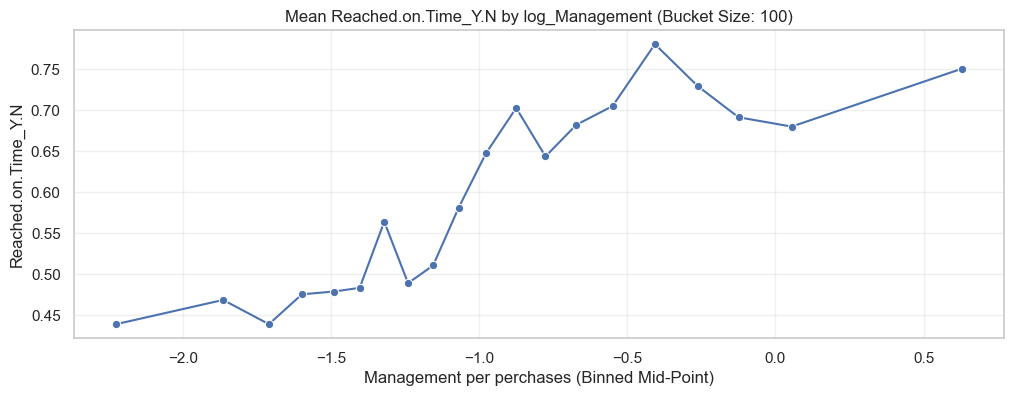

In [ ]:
# 1. 구간 나누기
copy_df['log_Management_per_purchases_Bin'] = pd.qcut(copy_df['log_Management_per_purchases'], q=20, duplicates='drop')

# 2. X축에 쓰기 위해 '구간의 중간값(Mid Point)'을 축출해서 새로운 수치형 컬럼 생성 ★핵심★
# 예: (0.1, 0.2] -> 0.15
copy_df['log_Management_per_purchases_Bin'] = copy_df['log_Management_per_purchases_Bin'].apply(lambda x: x.mid).astype(float)

# 3. 시각화 (X축을 구간 대신 중간값으로 설정)
plt.figure(figsize=(12, 4))
sns.lineplot(data=copy_df, x='log_Management_per_purchases_Bin', y=target, marker='o', errorbar=None)

plt.title(f'Mean {target} by log_Management (Bucket Size: 100)')
plt.xlabel('Management per perchases (Binned Mid-Point)')
plt.grid(True, alpha=0.3)
plt.show()

#### 다른 특성과의 관계
##### 'Product_importance'와 'Customer_care_calls'
* 중요도가 높을수록 call이 적어지는 경향
* 중요도 high인 경우 지연율이 평균 이상임을 감안하면 이상한 결과

* 가설1: 중요도는 제품의 중요도가 아닌 다른 기준이 있는가?
* 가설2: call 많이 할 수록 중요도를 낮추는가?
    * 두 가설은 'Product_importance' 분석에서 검증

##### 'Customer_care_calls'와 'Discount_offered', 'Cost_of_the_Product', 'Weight_in_gms'
* 가격이 높아질 수록 call 횟수가 증가. 할인액이 낮을수록 call 횟수가 증가 -> 가격에 민감한 소비자의 특성?
* 무게가 낮을수록 call 횟수가 증가

가설 1: 무게가 낮지만 가치가 높은 제품?

무게 대비 가격을 만들고 지연률과의 관계 확인

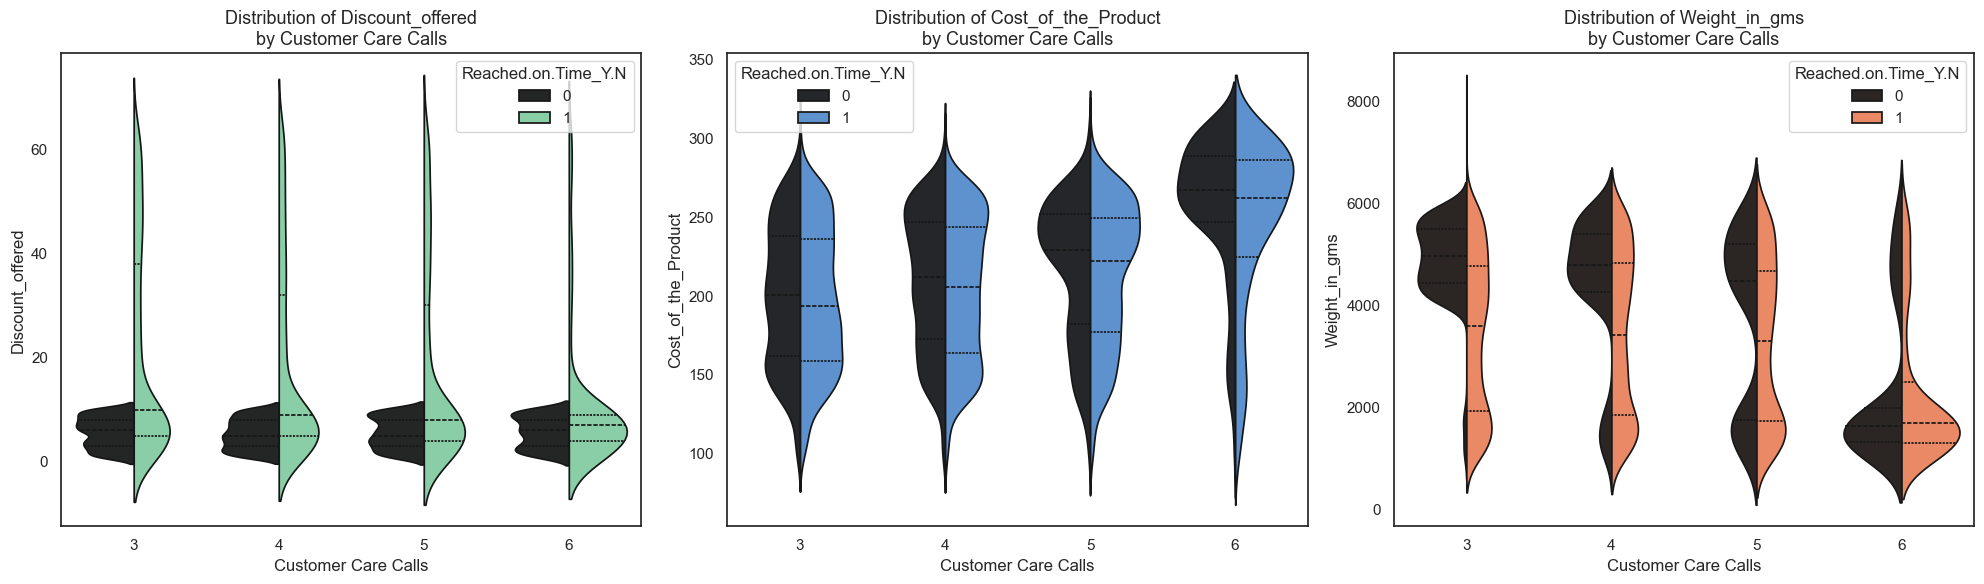

In [ ]:

# 1. 시각화 스타일 설정
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 분석할 연속형 변수 리스트
features = ['Discount_offered', 'Cost_of_the_Product', 'Weight_in_gms']
colors = ["#7ed9a4", "#4a90e2", "#ff7f50"] # 변수별로 다른 색상 적용

for i, col in enumerate(features):
    # 바이올린 플롯 생성: 전화 횟수에 따른 분포의 너비(밀도)를 확인
    sns.violinplot(data=train_df, x='Customer_care_calls', y=col, 
                   ax=axes[i], palette=f"dark:{colors[i]}", inner='quartile', split=True, hue=target)
    
    axes[i].set_title(f'Distribution of {col}\nby Customer Care Calls', fontsize=13)
    axes[i].set_xlabel('Customer Care Calls')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

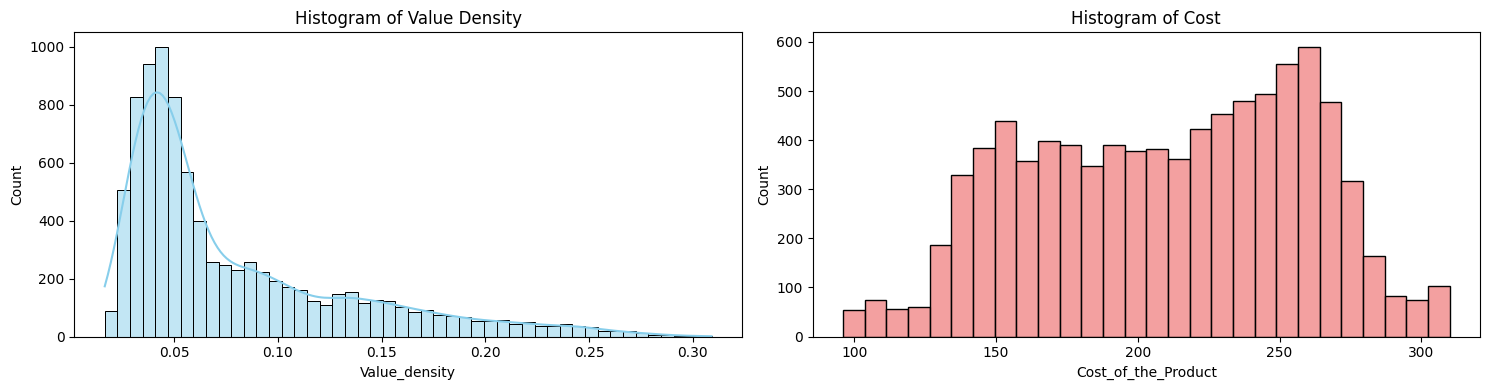

## Feature engineering

In [243]:
# 꼬임 방지를 위해 새로 지정
train_df = pd.read_csv('data/train_df.csv')
test_df = pd.read_csv('data/test_df.csv')
target = 'Reached.on.Time_Y.N'
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8799 entries, 0 to 8798
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   8799 non-null   int64 
 1   Warehouse_block      8799 non-null   object
 2   Mode_of_Shipment     8799 non-null   object
 3   Customer_care_calls  8799 non-null   int64 
 4   Customer_rating      8799 non-null   int64 
 5   Cost_of_the_Product  8799 non-null   int64 
 6   Prior_purchases      8799 non-null   int64 
 7   Product_importance   8799 non-null   object
 8   Gender               8799 non-null   object
 9   Discount_offered     8799 non-null   int64 
 10  Weight_in_gms        8799 non-null   int64 
 11  Reached.on.Time_Y.N  8799 non-null   int64 
dtypes: int64(8), object(4)
memory usage: 825.0+ KB


### 1. 새로운 파생 변수
* 할인액이 10 초과인 'Discount_Group'
* 무게의 범주화 및 인코딩 'Weight_Category'
* 할인가 Discounted_price와, log_price_per_weight 생성
* 창고별 배송수단 조합 및 숫자로 변환(인코딩) 'Wh_Shipment_Combo'

* 'Prior_purchases' 6이상 항목을 6으로 통합
* 'Customer_care_calls' 3 이하를 3으로, 6 이상을 6으로 범주 정리

* 가치밀도(무게 대비 가격) 생성 'log_Value_density'
* 실구매가(할인된 가격) 생성 'Discounted_price'
* 할인율 생성  'Discount_rate'
* 구매별 평균 문의 횟수 'Calls_per_purchase' 추가



In [ ]:
from sklearn.preprocessing import LabelEncoder

def apply_feature_engineering(df):
    # 1. Discount_Group 생성
    df['Discount_Group'] = (df['Discount_offered'] > 10).astype(int)
    
    # 2. Weight_Category 생성
    conditions = [
    (df['Weight_in_gms'] >= 4000) & (df['Weight_in_gms'] < 6000), 
    (df['Weight_in_gms'] >= 0) & (df['Weight_in_gms'] < 2000)     
    ]

    # 해당 조건에 대응하는 값 리스트
    choices = [0, 1]
    # 위의 조건들에 해당하지 않는 나머지(2000~4000 및 6000 이상)는 default 값 2으로 할당
    df['Weight_Category'] = np.select(conditions, choices, default=2)


    # 3. Discounted_price 생성
    df['Discounted_price'] = df['Cost_of_the_Product'] - df['Discount_offered']

    # 4. log_price_per_weight 생성
    df['log_price_per_weight'] = np.log(df['Cost_of_the_Product'] / (df['Weight_in_gms'] / 1000))

    # 5. 창고별 배송수단 조합 
    df['Wh_Shipment_Combo'] = df['Warehouse_block'].astype(str) + '_' + df['Mode_of_Shipment'].astype(str)
    
    # 모델 학습을 위해 범주형을 숫자로 매핑 (Label Encoding과 유사)
    # AutoGluon을 쓰신다면 문자열 그대로 두어도 되지만, Scikit-learn 모델을 위해 숫자로 변환합니다.
    le = LabelEncoder()
    df['Wh_Shipment_Combo'] = le.fit_transform(df['Wh_Shipment_Combo']) + 1


    # 6. prior purchase 6이상 묶기
    df['Prior_purchases'] = df['Prior_purchases'].clip(upper=6)

    # 7. customer care call 범주 정리
    df['Customer_care_calls'] = df['Customer_care_calls'].clip(lower=3, upper=6)



    # 8. 가치밀도(무게 대비 가격) 생성
    df['log_Value_density'] = np.log(df['Cost_of_the_Product'] / df['Weight_in_gms'])
        
    # 9. 실구매가(할인된 가격) 생성
    df['Discounted_price'] = df['Cost_of_the_Product'] - df['Discount_offered']

    # 10. 할인율 생성 
    df['Discount_rate'] = (df['Discount_offered'] / df['Cost_of_the_Product'])*100

    # 11. 구매별 평균 문의 횟수
    df['Calls_per_Purchase'] = (df['Customer_care_calls'] / df['Prior_purchases']).round(2)

    return df

# 각각의 데이터셋에 적용
train_df = apply_feature_engineering(train_df)
test_df = apply_feature_engineering(test_df)


### 2. 필요없는 특성 drop

In [245]:
train_df.columns.to_list()

['ID',
 'Warehouse_block',
 'Mode_of_Shipment',
 'Customer_care_calls',
 'Customer_rating',
 'Cost_of_the_Product',
 'Prior_purchases',
 'Product_importance',
 'Gender',
 'Discount_offered',
 'Weight_in_gms',
 'Reached.on.Time_Y.N',
 'Discount_Group',
 'Weight_Category',
 'Wh_Shipment_Combo',
 'log_Value_density',
 'Discounted_price',
 'Discount_rate']

중복 특성 정리

'Wh_Shipment_Combo': 'Warehouse_block', 'Mode_of_Shipment' <br>
'Weight_in_gms': 'Weight_Category' <br>
'Cost_of_the_Product': 'Discounted_price' <br>
'Discount_offered': 'Discount_rate' <br>

In [246]:
drop_columns = ["ID", "Gender"] #"Discount_offered", "Weight_in_gms",'Warehouse_block', 'Mode_of_Shipment', 'Customer_rating'
train_df = train_df.drop(drop_columns, axis=1)
test_df = test_df.drop(drop_columns, axis=1)

### 3. 인코딩

In [247]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder



def apply_feature_preprocessing(df):

    # 1. Product_importance: Label Encoding (순서가 있으므로 수동 매핑)
    importance_map = {'low': 0, 'medium': 1, 'high': 2}
    df['Product_importance'] = df['Product_importance'].map(importance_map)

    # 2. One-Hot Encoding (Warehouse_block, Mode_of_Shipment)
    # drop_first=True를 통해 다중공선성을 방지합니다.
    df = pd.get_dummies(df, columns=['Warehouse_block', 'Mode_of_Shipment'])

    return df
    
# 각각의 데이터셋에 적용
train_df = apply_feature_preprocessing(train_df)
test_df = apply_feature_preprocessing(test_df)




### 4. 스케일링

In [ ]:
# Scaling 대상 컬럼 선정
num_features = ['Discount_offered', 'Weight_in_gms', 'Cost_of_the_Product', 'log_Value_density', 
                    'Discounted_price', 'Discount_rate', 'Calls_per_Purchase']

scaler = StandardScaler()

# 중요: fit은 오직 train_df에만 수행합니다!
train_df[num_features] = scaler.fit_transform(train_df[num_features])

# test는 transform만 수행하여 데이터 누수를 차단합니다.
test_df[num_features] = scaler.transform(test_df[num_features])

In [249]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8799 entries, 0 to 8798
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer_care_calls      8799 non-null   int64  
 1   Customer_rating          8799 non-null   int64  
 2   Cost_of_the_Product      8799 non-null   float64
 3   Prior_purchases          8799 non-null   int64  
 4   Product_importance       8799 non-null   int64  
 5   Discount_offered         8799 non-null   float64
 6   Weight_in_gms            8799 non-null   float64
 7   Reached.on.Time_Y.N      8799 non-null   int64  
 8   Discount_Group           8799 non-null   int64  
 9   Weight_Category          8799 non-null   int64  
 10  Wh_Shipment_Combo        8799 non-null   int64  
 11  log_Value_density        8799 non-null   float64
 12  Discounted_price         8799 non-null   float64
 13  Discount_rate            8799 non-null   float64
 14  Warehouse_block_A       